# Tmap API + 회피 알고리즘 재설계
## 260727

In [1]:
# 셀 1: 라이브러리 import 및 환경 점검
# v2 노트북 시작 — Tmap 도보 polyline 기반 회피 영역 검증

# 표준 라이브러리
import os
import json
import time
import math
import itertools
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

# HTTP·환경
import requests
from dotenv import load_dotenv

# 데이터 처리
import numpy as np
import pandas as pd

# 거리·공간 처리
from shapely.geometry import shape, Point, LineString
from shapely.ops import unary_union
from shapely.prepared import prep
from sklearn.neighbors import BallTree   # 단계 6에서 neighbor_200m 계산용

# 지도 시각화
import folium

print(f"[v2 노트북 시작 — Tmap 도보 polyline 기반]")
print(f"  pandas    {pd.__version__}")
print(f"  numpy     {np.__version__}")
print(f"  folium    {folium.__version__}")
print(f"  requests  {requests.__version__}")
print(f"  작업 디렉토리: {os.getcwd()}")

[v2 노트북 시작 — Tmap 도보 polyline 기반]
  pandas    3.0.3
  numpy     2.4.6
  folium    0.20.0
  requests  2.34.2
  작업 디렉토리: c:\Users\User\Documents\GitHub\ploggo-algorithm-test


In [2]:
# 셀 2 (수정): 인증키 로드 + 출력 디렉토리를 output2로 분리
# v1 산출물(./output)과 v2 산출물(./output2)을 명확히 구분

load_dotenv(override=True)

VWORLD_KEY = os.getenv('VWORLD_KEY')
TMAP_APP_KEY = os.getenv('TMAP_APP_KEY')

if not VWORLD_KEY:
    raise RuntimeError(".env에 VWORLD_KEY가 없다.")
if not TMAP_APP_KEY:
    raise RuntimeError(".env에 TMAP_APP_KEY가 없다.")

print(f"[인증키 로드 완료]")
print(f"  V-World:  {VWORLD_KEY[:4]}...{VWORLD_KEY[-4:]} ({len(VWORLD_KEY)}자)")
print(f"  Tmap:     {TMAP_APP_KEY[:6]}...{TMAP_APP_KEY[-4:]} ({len(TMAP_APP_KEY)}자)")

# 출력 디렉토리 — v2 전용 폴더로 분리 (v1의 ./output과 공존)
OUTPUT_DIR = Path("./output2")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"  출력 디렉토리: {OUTPUT_DIR.resolve()}")
print(f"  (v1 산출물은 ./output에 그대로 보존)")

[인증키 로드 완료]
  V-World:  8C07...3D4E (36자)
  Tmap:     r8mALt...H5Zm (40자)
  출력 디렉토리: C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output2
  (v1 산출물은 ./output에 그대로 보존)


In [3]:
# 셀 3: v1 회피 영역 GeoJSON 로드 + shapely 변환
# v1 노트북에서 V-World로 수집한 147개 폴리곤을 그대로 활용 (시간 절약)

from shapely.geometry import shape
from shapely.ops import unary_union
from shapely.prepared import prep

# v1 산출물 경로 (output 폴더에 있음)
GEOJSON_PATH = Path("./output/incheon_avoid_zones_v1_260601.geojson")

if not GEOJSON_PATH.exists():
    raise FileNotFoundError(
        f"v1 GeoJSON 파일이 없다: {GEOJSON_PATH.resolve()}\n"
        f"v1 노트북의 셀 11까지 실행한 산출물이 있어야 한다."
    )

with open(GEOJSON_PATH, 'r', encoding='utf-8') as f:
    avoid_geojson = json.load(f)

# 147개 features → shapely 폴리곤 + 메타데이터
avoid_polygons = []
for feature in avoid_geojson['features']:
    props = feature['properties']
    geom = shape(feature['geometry'])
    avoid_polygons.append({
        'geom':       geom,
        'uqa_code':   props.get('uqa_code'),
        'uname':      props.get('uname'),
        'sigg_name':  props.get('sigg_name'),
        'feature_id': props.get('feature_id'),
    })

# 전체 폴리곤 union (교차 검사·페널티 계산용)
avoid_union = unary_union([p['geom'] for p in avoid_polygons])
avoid_union_prepared = prep(avoid_union)  # 점-폴리곤 검사 가속

# UQA 코드별 union (분석용)
avoid_union_by_code = {}
for code in ['UQA310', 'UQA320', 'UQA330']:
    geoms = [p['geom'] for p in avoid_polygons if p['uqa_code'] == code]
    if geoms:
        avoid_union_by_code[code] = unary_union(geoms)

# 통계 출력
print(f"[회피 영역 로드 완료]")
print(f"  총 폴리곤: {len(avoid_polygons)}개")
print(f"  UQA 코드별:")
for code in ['UQA310', 'UQA320', 'UQA330']:
    n = sum(1 for p in avoid_polygons if p['uqa_code'] == code)
    print(f"    {code}: {n}개")

print(f"\n  군구별:")
sigg_counts = Counter(p['sigg_name'] for p in avoid_polygons)
for sigg, n in sigg_counts.most_common():
    print(f"    {sigg:<15} {n}개")

print(f"\n  avoid_union bounds (lon_min, lat_min, lon_max, lat_max):")
print(f"    {avoid_union.bounds}")

[회피 영역 로드 완료]
  총 폴리곤: 147개
  UQA 코드별:
    UQA310: 5개
    UQA320: 46개
    UQA330: 96개

  군구별:
    서구              44개
    중구              29개
    미추홀구            15개
    남동구             14개
    동구              12개
    계양구             12개
    연수구             11개
    부평구             7개
    강화군             3개

  avoid_union bounds (lon_min, lat_min, lon_max, lat_max):
    (126.47063840934426, 37.34180714965152, 126.76623837593196, 37.767857612646296)


In [4]:
# 셀 4: 핫스팟 CSV 로드 + neighbor_200m + S_i 계산
# routeTest_v3 셀 3·5·6 이식 (핸드오프 v4 알고리즘 사양 그대로)

import ast
from sklearn.neighbors import BallTree

# === 1. CSV 로드 ===
CSV_PATH = Path("./hotspots_CCTV_20260510.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(f"핫스팟 CSV가 없다: {CSV_PATH.resolve()}")

hotspots = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

# list 필드 복원 (문자열 → list)
def parse_list_field(value):
    if pd.isna(value):
        return None
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return None
    return value

hotspots['install_years']      = hotspots['install_years'].apply(parse_list_field)
hotspots['relocation_history'] = hotspots['relocation_history'].apply(parse_list_field)

print(f"[핫스팟 로드] {len(hotspots):,}곳, {len(hotspots.columns)}컬럼")

# === 2. neighbor_200m 계산 (BallTree) ===
# 핸드오프 D2-2 공식: S_i = cctv_count + 0.5 × neighbor_200m
EARTH_RADIUS_KM = 6371.0

t0 = time.time()
coords_rad = np.radians(hotspots[['latitude', 'longitude']].values)
tree = BallTree(coords_rad, metric='haversine')
radius_rad = 0.2 / EARTH_RADIUS_KM   # 200m → 라디안

# query_radius는 자기 자신 포함 카운트 반환 → -1 보정
counts = tree.query_radius(coords_rad, r=radius_rad, count_only=True)
hotspots['neighbor_200m'] = counts - 1

print(f"\n[neighbor_200m 계산] 소요 {time.time() - t0:.2f}초")
print(f"  분포: min {hotspots['neighbor_200m'].min()}, "
      f"max {hotspots['neighbor_200m'].max()}, "
      f"평균 {hotspots['neighbor_200m'].mean():.2f}")

n_with_neighbor = (hotspots['neighbor_200m'] > 0).sum()
print(f"  200m 내 이웃 보유: {n_with_neighbor:,}곳 ({n_with_neighbor/len(hotspots)*100:.1f}%)")

# === 3. S_i 계산 ===
hotspots['S_i'] = hotspots['cctv_count'] + 0.5 * hotspots['neighbor_200m']

print(f"\n[S_i 계산 완료]")
print(f"  분포: min {hotspots['S_i'].min():.2f}, "
      f"max {hotspots['S_i'].max():.2f}, "
      f"평균 {hotspots['S_i'].mean():.2f}")

print(f"\n  군구별 S_i 평균:")
for sigg, mean_si in hotspots.groupby('source_district')['S_i'].mean().items():
    print(f"    {sigg:<12} {mean_si:.2f}")

# === 4. 회피 영역 내부 핫스팟 표시 (방법 C에서 활용) ===
# 각 핫스팟이 회피 영역 내부에 있는지 미리 계산
def is_in_avoid_zone(row):
    pt = Point(row['longitude'], row['latitude'])
    return avoid_union_prepared.contains(pt)

t0 = time.time()
hotspots['in_avoid_zone'] = hotspots.apply(is_in_avoid_zone, axis=1)
print(f"\n[회피 영역 내부 검사] 소요 {time.time() - t0:.2f}초")
print(f"  회피 영역 내부 핫스팟: {hotspots['in_avoid_zone'].sum()}/{len(hotspots):,} "
      f"({hotspots['in_avoid_zone'].sum()/len(hotspots)*100:.2f}%)")

[핫스팟 로드] 1,535곳, 15컬럼

[neighbor_200m 계산] 소요 0.01초
  분포: min 0, max 17, 평균 3.16
  200m 내 이웃 보유: 1,178곳 (76.7%)

[S_i 계산 완료]
  분포: min 1.00, max 11.00, 평균 2.78

  군구별 S_i 평균:
    bupyeong     1.25
    donggu       1.88
    ganghwa      1.07
    gyeyang      3.51
    junggu       1.94
    michuhol     2.11
    namdong      1.70
    seogu        2.65
    yeonsu       4.86

[회피 영역 내부 검사] 소요 0.04초
  회피 영역 내부 핫스팟: 58/1,535 (3.78%)


In [5]:
# 셀 5: 거리·Buffer 유틸 함수 + OD 9쌍 + 후보 추출 검증
# haversine 패키지 의존 제거 — numpy 기반 직접 구현 (수학적으로 동일)

# === 0. Haversine 직접 구현 ===
def haversine_km(p_a, p_b):
    """두 (lat, lon) 좌표 사이의 Haversine 거리 (km)
    
    haversine 패키지의 hs.haversine(p_a, p_b, unit=hs.Unit.KILOMETERS)와 동일 결과.
    지구 반경 6371.0 km 사용.
    """
    lat1, lon1 = p_a
    lat2, lon2 = p_b
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    return EARTH_RADIUS_KM * c   # EARTH_RADIUS_KM은 셀 4에서 6371.0으로 정의됨

# === 1. 도보·Buffer 유틸 함수 ===
DETOUR_RATIO = 1.3   # 한국 도시 도보 환경 평균 보정계수 (핸드오프 D3)

def walking_distance_km(p_a, p_b):
    """추정 도보 거리 (km) = Haversine × 1.3"""
    return haversine_km(p_a, p_b) * DETOUR_RATIO

def detour_distance_km(origin, hotspot, destination):
    """핫스팟 단독 경유 시 우회 거리: D_i = d(O,h) + d(h,D) - d(O,D)"""
    d_oh = walking_distance_km(origin, hotspot)
    d_hd = walking_distance_km(hotspot, destination)
    d_od = walking_distance_km(origin, destination)
    return max(d_oh + d_hd - d_od, 0.0)

def get_buffer_radius(district):
    """군구별 buffer 반경 (km) — 강화군 2.5km, 그 외 1.5km (핸드오프 D4)"""
    return 2.5 if district == 'ganghwa' else 1.5

def filter_candidates_by_ellipse_buffer(df, origin, destination, buffer_r_km):
    """타원 buffer 필터링: d(O,h) + d(h,D) - d(O,D) < buffer_r × 1.5"""
    d_od = walking_distance_km(origin, destination)
    threshold = buffer_r_km * 1.5
    
    coords = df[['latitude', 'longitude']].values
    d_oh = np.array([walking_distance_km(origin, tuple(c)) for c in coords])
    d_hd = np.array([walking_distance_km(tuple(c), destination) for c in coords])
    
    mask = (d_oh + d_hd - d_od) < threshold
    return df[mask].copy()

# === 2. OD 9쌍 좌표 (routeTest_v3 OD_CANDIDATES_V2와 동일) ===
OD_CANDIDATES_V2 = {
    'ganghwa':  {'O': (37.706505, 126.443398), 'D': (37.732838, 126.517697)},
    'junggu':   {'O': (37.473565, 126.621778), 'D': (37.474748, 126.603258)},
    'donggu':   {'O': (37.470733, 126.641914), 'D': (37.487780, 126.621754)},
    'michuhol': {'O': (37.455015, 126.667435), 'D': (37.435062, 126.690721)},
    'seogu':    {'O': (37.545115, 126.676062), 'D': (37.552748, 126.650239)},
    'yeonsu':   {'O': (37.391182, 126.645092), 'D': (37.418275, 126.661122)},
    'namdong':  {'O': (37.447245, 126.731453), 'D': (37.447769, 126.700089)},
    'bupyeong': {'O': (37.507046, 126.721858), 'D': (37.482179, 126.703038)},
    'gyeyang':  {'O': (37.537367, 126.737744), 'D': (37.530279, 126.722516)},
}

# === 3. 각 OD에 대해 Buffer 후보 추출 + 표본 편향 검증 ===
print(f"[Buffer 후보 추출 검증]")
print(f"{'군구':<10} {'직선(km)':>9} {'buffer(km)':>11} {'후보수':>7} {'회피_내부':>9}")
print("-" * 55)

od_buffer_results = {}
for district, od in OD_CANDIDATES_V2.items():
    origin = od['O']
    destination = od['D']
    
    direct_km = haversine_km(origin, destination)
    buffer_r = get_buffer_radius(district)
    
    district_df = hotspots[hotspots['source_district'] == district]
    cands = filter_candidates_by_ellipse_buffer(district_df, origin, destination, buffer_r)
    n_avoid_in_buffer = int(cands['in_avoid_zone'].sum())
    
    od_buffer_results[district] = {
        'origin': origin,
        'destination': destination,
        'direct_km': direct_km,
        'buffer_r_km': buffer_r,
        'candidates': cands,
        'n_candidates': len(cands),
        'n_avoid_in_buffer': n_avoid_in_buffer,
    }
    
    print(f"{district:<10} {direct_km:>7.2f}   {buffer_r:>9}   {len(cands):>5}   "
          f"{n_avoid_in_buffer:>6}")

print(f"\n[중요 — 표본 편향 가설 검증]")
total_avoid_in_buffer = sum(r['n_avoid_in_buffer'] for r in od_buffer_results.values())
print(f"  9 OD의 Buffer 안 회피 핫스팟 총합: {total_avoid_in_buffer}곳")
if total_avoid_in_buffer == 0:
    print(f"  → 표본 편향 가설 정량 입증: Buffer 안에 회피 핫스팟이 0건이므로")
    print(f"    옵션 X 0건은 알고리즘 견고성이 아닌 OD 선정 편향의 결과")
elif total_avoid_in_buffer < 5:
    print(f"  → 표본 편향 가설 부분 입증: Buffer 안 회피 핫스팟이 매우 적음")
else:
    print(f"  → 알고리즘이 일부 회피 효과 보일 가능성 (S_i 정렬에서 탈락 등)")

[Buffer 후보 추출 검증]
군구            직선(km)  buffer(km)     후보수     회피_내부
-------------------------------------------------------
ganghwa       7.16         2.5      27        0
junggu        1.64         1.5      28        1
donggu        2.60         1.5      46        7
michuhol      3.02         1.5     130        0
seogu         2.43         1.5      61        0
yeonsu        3.33         1.5      67        0
namdong       2.77         1.5      73        0
bupyeong      3.23         1.5      23        0
gyeyang       1.56         1.5     110        7

[중요 — 표본 편향 가설 검증]
  9 OD의 Buffer 안 회피 핫스팟 총합: 15곳
  → 알고리즘이 일부 회피 효과 보일 가능성 (S_i 정렬에서 탈락 등)


## 정적 회피 페널티 함수 (방법 C 핵심)

In [6]:
# 셀 6: 정적 회피 페널티 함수 (방법 C 핵심)
# Tmap 호출 없이 shapely 직선 교차로 회피 페널티 계산
# 위경도 1도 ≈ 111km (위도 37도 부근) 근사 사용

def compute_avoid_penalty(hotspot_lat, hotspot_lon, origin, destination,
                          avoid_union, avoid_union_prepared):
    """
    핫스팟의 정적 회피 페널티 계산.
    
    구성 요소:
    1. 핫스팟이 회피 영역 내부면 매우 큰 페널티 (999) — 옵션 X 완전 차단
    2. O → 핫스팟 직선의 회피 영역 통과 길이
    3. 핫스팟 → D 직선의 회피 영역 통과 길이
    
    단위: km (다른 항과 일치)
    호출 비용: O(1), 약 1~2 밀리초
    
    Args:
        hotspot_lat, hotspot_lon: 핫스팟 좌표
        origin: (lat, lon) 출발지
        destination: (lat, lon) 도착지
        avoid_union: shapely MultiPolygon (회피 영역 union)
        avoid_union_prepared: prep된 union (점-폴리곤 검사 가속)
    
    Returns:
        float: 페널티 (km)
    """
    # 1. 회피 영역 내부 검사 (옵션 X 차단)
    hotspot_point = Point(hotspot_lon, hotspot_lat)
    if avoid_union_prepared.contains(hotspot_point):
        return 999.0
    
    # 2. O → 핫스팟 직선의 회피 영역 통과
    line_o = LineString([
        (origin[1], origin[0]),
        (hotspot_lon, hotspot_lat),
    ])
    inter_o = line_o.intersection(avoid_union)
    len_o_deg = inter_o.length if not inter_o.is_empty else 0
    
    # 3. 핫스팟 → D 직선의 회피 영역 통과
    line_d = LineString([
        (hotspot_lon, hotspot_lat),
        (destination[1], destination[0]),
    ])
    inter_d = line_d.intersection(avoid_union)
    len_d_deg = inter_d.length if not inter_d.is_empty else 0
    
    # 위경도 → km 근사 (위도 37도 부근 1도 ≈ 111km)
    return (len_o_deg + len_d_deg) * 111.0


# === 동작 검증 — donggu·gyeyang의 회피 후보 vs 일반 후보 페널티 비교 ===
print("[정적 회피 페널티 함수 검증]")
print("=" * 70)

for district in ['donggu', 'gyeyang', 'michuhol']:   # 회피 7곳·7곳·0곳 비교
    od = OD_CANDIDATES_V2[district]
    cands = od_buffer_results[district]['candidates']
    
    # 회피 영역 내부 후보의 페널티
    avoid_cands = cands[cands['in_avoid_zone']]
    
    print(f"\n[{district}] OD: O{od['O']} → D{od['D']}")
    print(f"  Buffer 후보 {len(cands)}곳 중 회피 내부 {len(avoid_cands)}곳")
    
    if len(avoid_cands) > 0:
        print(f"\n  회피 영역 내부 후보 (S_i 상위 3개):")
        for _, row in avoid_cands.nlargest(3, 'S_i').iterrows():
            penalty = compute_avoid_penalty(
                row['latitude'], row['longitude'],
                od['O'], od['D'],
                avoid_union, avoid_union_prepared,
            )
            print(f"    {row['hotspot_id']}: S_i={row['S_i']:.2f}, "
                  f"penalty={penalty:.2f}")
    
    # 비교: 회피 영역 밖 후보 상위 3
    non_avoid = cands[~cands['in_avoid_zone']]
    print(f"\n  회피 영역 밖 후보 (S_i 상위 3개):")
    for _, row in non_avoid.nlargest(3, 'S_i').iterrows():
        penalty = compute_avoid_penalty(
            row['latitude'], row['longitude'],
            od['O'], od['D'],
            avoid_union, avoid_union_prepared,
        )
        print(f"    {row['hotspot_id']}: S_i={row['S_i']:.2f}, "
              f"penalty={penalty:.2f}")

[정적 회피 페널티 함수 검증]

[donggu] OD: O(37.470733, 126.641914) → D(37.48778, 126.621754)
  Buffer 후보 46곳 중 회피 내부 7곳

  회피 영역 내부 후보 (S_i 상위 3개):
    donggu_wydj1rqd_001: S_i=1.50, penalty=999.00
    donggu_wydj32ez_001: S_i=1.50, penalty=999.00
    donggu_wydj3359_001: S_i=1.50, penalty=999.00

  회피 영역 밖 후보 (S_i 상위 3개):
    donggu_wydj1ydk_001: S_i=3.50, penalty=0.79
    donggu_wydj1vg9_001: S_i=3.00, penalty=0.53
    donggu_wydj1x1h_001: S_i=3.00, penalty=0.36

[gyeyang] OD: O(37.537367, 126.737744) → D(37.530279, 126.722516)
  Buffer 후보 110곳 중 회피 내부 7곳

  회피 영역 내부 후보 (S_i 상위 3개):
    gyeyang_wydj7zt6_001: S_i=3.50, penalty=999.00
    gyeyang_wydj7ztf_001: S_i=3.00, penalty=999.00
    gyeyang_wydjkp9v_001: S_i=3.00, penalty=999.00

  회피 영역 밖 후보 (S_i 상위 3개):
    gyeyang_wydje8me_001: S_i=7.00, penalty=0.00
    gyeyang_wydjeep3_001: S_i=7.00, penalty=0.00
    gyeyang_wydje9mr_001: S_i=6.50, penalty=0.00

[michuhol] OD: O(37.455015, 126.667435) → D(37.435062, 126.690721)
  Buffer 후보 130곳 중 회피 내

In [7]:
# 셀 7: Score 공식 통합 — 방법 C 적용
# 새 공식: Score_i = α·S_i - β·D_i - γ·avoid_penalty_i

# === 하이퍼파라미터 ===
ALPHA = 0.5   # S_i 가중치 (핸드오프 D6 그대로)
BETA  = 0.5   # D_i 가중치 (핸드오프 D6 그대로)
GAMMA = 1.0   # avoid_penalty 가중치 (방법 C 신규, 단계 6 후반 튜닝 대상)

# === 회피 페널티 통합 Score 함수 (방법 C) ===
def compute_scores_with_avoidance(df, origin, destination,
                                   avoid_union, avoid_union_prepared,
                                   alpha=ALPHA, beta=BETA, gamma=GAMMA):
    """방법 C 적용 Score 계산.
    Score_i = α·S_i - β·D_i - γ·avoid_penalty_i
    """
    out = df.copy()
    out['D_i'] = out.apply(
        lambda r: detour_distance_km(origin, (r['latitude'], r['longitude']), destination),
        axis=1
    )
    out['avoid_penalty_i'] = out.apply(
        lambda r: compute_avoid_penalty(
            r['latitude'], r['longitude'],
            origin, destination,
            avoid_union, avoid_union_prepared,
        ),
        axis=1
    )
    out['Score_i'] = alpha * out['S_i'] - beta * out['D_i'] - gamma * out['avoid_penalty_i']
    return out

# === 원본 Score 함수 (방법 C 적용 전, 회귀 검증용) ===
def compute_scores_original(df, origin, destination, alpha=ALPHA, beta=BETA):
    """routeTest_v3 원본 Score (회귀 검증용)."""
    out = df.copy()
    out['D_i'] = out.apply(
        lambda r: detour_distance_km(origin, (r['latitude'], r['longitude']), destination),
        axis=1
    )
    out['avoid_penalty_i'] = 0.0   # 없음 (호환성)
    out['Score_i'] = alpha * out['S_i'] - beta * out['D_i']
    return out

print(f"[Score 공식 정의 완료]")
print(f"  원본: Score_i = α·S_i - β·D_i")
print(f"  방법 C: Score_i = α·S_i - β·D_i - γ·avoid_penalty_i")
print(f"  가중치: α={ALPHA}, β={BETA}, γ={GAMMA} (초기값)")
print(f"  γ 튜닝은 단계 6-D에서 진행 (0.5, 1.0, 2.0, 5.0 비교)")

[Score 공식 정의 완료]
  원본: Score_i = α·S_i - β·D_i
  방법 C: Score_i = α·S_i - β·D_i - γ·avoid_penalty_i
  가중치: α=0.5, β=0.5, γ=1.0 (초기값)
  γ 튜닝은 단계 6-D에서 진행 (0.5, 1.0, 2.0, 5.0 비교)


In [8]:
# 셀 8: Greedy 알고리즘 + 방법 C vs 원본 비교
# routeTest_v3의 algorithm_greedy 이식 + 회피 페널티 적용 버전 추가

K = 3
BF_TOP_N = 15

def algorithm_greedy_v2(candidates_df, origin, destination,
                         avoid_union, avoid_union_prepared,
                         alpha=ALPHA, beta=BETA, gamma=GAMMA, k=K):
    """방법 C 적용 Greedy.
    1. S_i 상위 BF_TOP_N=15 풀 (원본과 동일)
    2. compute_scores_with_avoidance로 Score_i 계산 (회피 페널티 포함)
    3. Score_i 상위 K=3 선택
    """
    t0 = time.time()
    n = len(candidates_df)
    if n == 0:
        return pd.DataFrame(), 0
    k_eff = min(k, n)
    
    pool = candidates_df.nlargest(min(BF_TOP_N, n), 'S_i')
    scored = compute_scores_with_avoidance(
        pool, origin, destination, avoid_union, avoid_union_prepared,
        alpha=alpha, beta=beta, gamma=gamma,
    )
    selected = scored.nlargest(k_eff, 'Score_i')
    return selected, (time.time() - t0) * 1000

def algorithm_greedy_original(candidates_df, origin, destination,
                               alpha=ALPHA, beta=BETA, k=K):
    """routeTest_v3 원본 Greedy (회귀 검증용)."""
    t0 = time.time()
    n = len(candidates_df)
    if n == 0:
        return pd.DataFrame(), 0
    k_eff = min(k, n)
    
    pool = candidates_df.nlargest(min(BF_TOP_N, n), 'S_i')
    scored = compute_scores_original(pool, origin, destination, alpha=alpha, beta=beta)
    selected = scored.nlargest(k_eff, 'Score_i')
    return selected, (time.time() - t0) * 1000


# === 9 OD에 대해 원본 vs 방법 C 직접 비교 ===
print("=" * 80)
print("[Greedy 원본 vs 방법 C 비교 — 9 OD]")
print("=" * 80)

comparison_results = []
for district, od in OD_CANDIDATES_V2.items():
    cands = od_buffer_results[district]['candidates']
    
    # 원본
    sel_orig, _ = algorithm_greedy_original(cands, od['O'], od['D'])
    orig_ids = set(sel_orig['hotspot_id'])
    orig_avoid_count = int(sel_orig['in_avoid_zone'].sum()) if 'in_avoid_zone' in sel_orig.columns else 0
    
    # 방법 C
    sel_v2, _ = algorithm_greedy_v2(cands, od['O'], od['D'], avoid_union, avoid_union_prepared)
    v2_ids = set(sel_v2['hotspot_id'])
    v2_avoid_count = int(sel_v2['in_avoid_zone'].sum()) if 'in_avoid_zone' in sel_v2.columns else 0
    
    # K=3 일치 여부
    if orig_ids == v2_ids:
        diff_status = "동일"
    else:
        diff_status = f"다름 (원본만: {len(orig_ids - v2_ids)}, v2만: {len(v2_ids - orig_ids)})"
    
    # 방법 C의 페널티 합계
    v2_total_penalty = sel_v2['avoid_penalty_i'].sum()
    
    comparison_results.append({
        'district': district,
        'orig_avoid_in_K3': orig_avoid_count,
        'v2_avoid_in_K3': v2_avoid_count,
        'diff_status': diff_status,
        'v2_total_penalty': v2_total_penalty,
    })
    
    print(f"\n[{district}]")
    print(f"  원본 K=3 회피 영역 내부: {orig_avoid_count}개")
    print(f"  방법 C K=3 회피 영역 내부: {v2_avoid_count}개")
    print(f"  K=3 비교: {diff_status}")
    print(f"  방법 C 총 페널티: {v2_total_penalty:.2f}")

# 종합
print(f"\n{'=' * 80}")
print(f"[종합]")
df_compare = pd.DataFrame(comparison_results)
n_diff = sum(1 for r in comparison_results if "다름" in r['diff_status'])
print(f"  K=3 선정이 다른 OD: {n_diff}/9")
print(f"  원본 K=3 회피 내부 총: {df_compare['orig_avoid_in_K3'].sum()}")
print(f"  방법 C K=3 회피 내부 총: {df_compare['v2_avoid_in_K3'].sum()} (페널티 999로 차단)")

[Greedy 원본 vs 방법 C 비교 — 9 OD]

[ganghwa]
  원본 K=3 회피 영역 내부: 0개
  방법 C K=3 회피 영역 내부: 0개
  K=3 비교: 동일
  방법 C 총 페널티: 0.00

[junggu]
  원본 K=3 회피 영역 내부: 0개
  방법 C K=3 회피 영역 내부: 0개
  K=3 비교: 다름 (원본만: 1, v2만: 1)
  방법 C 총 페널티: 0.92

[donggu]
  원본 K=3 회피 영역 내부: 0개
  방법 C K=3 회피 영역 내부: 0개
  K=3 비교: 다름 (원본만: 2, v2만: 2)
  방법 C 총 페널티: 1.22

[michuhol]
  원본 K=3 회피 영역 내부: 0개
  방법 C K=3 회피 영역 내부: 0개
  K=3 비교: 동일
  방법 C 총 페널티: 0.00

[seogu]
  원본 K=3 회피 영역 내부: 0개
  방법 C K=3 회피 영역 내부: 0개
  K=3 비교: 동일
  방법 C 총 페널티: 0.00

[yeonsu]
  원본 K=3 회피 영역 내부: 0개
  방법 C K=3 회피 영역 내부: 0개
  K=3 비교: 동일
  방법 C 총 페널티: 0.00

[namdong]
  원본 K=3 회피 영역 내부: 0개
  방법 C K=3 회피 영역 내부: 0개
  K=3 비교: 동일
  방법 C 총 페널티: 0.00

[bupyeong]
  원본 K=3 회피 영역 내부: 0개
  방법 C K=3 회피 영역 내부: 0개
  K=3 비교: 동일
  방법 C 총 페널티: 0.00

[gyeyang]
  원본 K=3 회피 영역 내부: 0개
  방법 C K=3 회피 영역 내부: 0개
  K=3 비교: 동일
  방법 C 총 페널티: 0.00

[종합]
  K=3 선정이 다른 OD: 2/9
  원본 K=3 회피 내부 총: 0
  방법 C K=3 회피 내부 총: 0 (페널티 999로 차단)


### Tmap 보행자 호출 + polyline 교차 검사

In [9]:
# 셀 9: Tmap 보행자 호출 함수 + polyline 교차 검사
# v1 노트북의 셀 21을 v2에 이식 + 교차 검사 함수 추가

TMAP_PEDESTRIAN_URL = "https://apis.openapi.sk.com/tmap/routes/pedestrian?version=1"

def get_pedestrian_route(origin, destination, waypoints=None, debug=False):
    """Tmap 보행자 경로안내 API 호출.
    
    Args:
        origin, destination: (lat, lon)
        waypoints: [(lat, lon), ...] 또는 None (최대 5개)
    Returns:
        dict: path([(lat, lon), ...]), distance_m, duration_ms, status
    """
    headers = {
        "Accept": "application/json",
        "Content-Type": "application/json",
        "appKey": TMAP_APP_KEY,
    }
    payload = {
        "startX": origin[1], "startY": origin[0],
        "endX": destination[1], "endY": destination[0],
        "startName": "출발지", "endName": "도착지",
        "reqCoordType": "WGS84GEO", "resCoordType": "WGS84GEO",
        "searchOption": "0",
    }
    if waypoints:
        if len(waypoints) > 5:
            return {'path': None, 'distance_m': 0, 'duration_ms': 0,
                    'status': f'ERROR: 경유지 {len(waypoints)}개. Tmap 한도 5개 초과'}
        payload["passList"] = "_".join(f"{wp[1]},{wp[0]}" for wp in waypoints)
    
    try:
        r = requests.post(TMAP_PEDESTRIAN_URL, headers=headers, json=payload, timeout=15)
    except requests.exceptions.RequestException as e:
        return {'path': None, 'distance_m': 0, 'duration_ms': 0,
                'status': f'ERROR: {type(e).__name__}'}
    
    if r.status_code != 200:
        return {'path': None, 'distance_m': 0, 'duration_ms': 0,
                'status': f'ERROR: HTTP {r.status_code}, body: {r.text[:150]}'}
    
    try:
        result = r.json()
    except json.JSONDecodeError:
        return {'path': None, 'distance_m': 0, 'duration_ms': 0, 'status': 'JSON_ERROR'}
    
    if result.get('type') != 'FeatureCollection':
        return {'path': None, 'distance_m': 0, 'duration_ms': 0, 'status': 'INVALID'}
    
    features = result.get('features', [])
    if not features:
        return {'path': None, 'distance_m': 0, 'duration_ms': 0, 'status': 'NO_FEATURES'}
    
    first_props = features[0].get('properties', {})
    total_distance_m = first_props.get('totalDistance', 0)
    total_time_s = first_props.get('totalTime', 0)
    
    path_lonlat = []
    for f in features:
        geom = f.get('geometry', {})
        if geom.get('type') == 'LineString':
            path_lonlat.extend(geom.get('coordinates', []))
    
    # (lat, lon) 형식으로 변환 (본 노트북 일관성)
    path_latlon = [(pt[1], pt[0]) for pt in path_lonlat]
    
    return {
        'path': path_latlon,
        'distance_m': total_distance_m,
        'duration_ms': total_time_s * 1000,
        'status': 'OK',
    }


def check_polyline_avoid_intersection(path_latlon, avoid_union_param, 
                                        avoid_union_by_code_param):
    """polyline이 회피 영역과 교차하는지 검사.
    
    Args:
        path_latlon: [(lat, lon), ...] polyline 좌표 리스트
        avoid_union_param: shapely MultiPolygon (전체 회피 영역)
        avoid_union_by_code_param: dict {uqa_code: union} (코드별 회피 영역)
    
    Returns:
        dict: crosses, intersection_length_m, intersection_ratio, crossed_uqa_codes
    """
    empty_result = {
        'crosses': False, 'intersection_length_m': 0, 
        'intersection_ratio': 0, 'crossed_uqa_codes': [],
    }
    
    if not path_latlon or len(path_latlon) < 2:
        return empty_result
    
    # polyline → shapely LineString (lon, lat 순서)
    line = LineString([(pt[1], pt[0]) for pt in path_latlon])
    
    if not line.intersects(avoid_union_param):
        return empty_result
    
    intersection = line.intersection(avoid_union_param)
    inter_length_m = intersection.length * 111000.0
    total_length_m = line.length * 111000.0
    ratio = inter_length_m / total_length_m if total_length_m > 0 else 0
    
    # 어느 UQA 코드와 교차?
    crossed_codes = []
    for code, union in avoid_union_by_code_param.items():
        if line.intersects(union):
            crossed_codes.append(code)
    
    return {
        'crosses': True,
        'intersection_length_m': inter_length_m,
        'intersection_ratio': ratio,
        'crossed_uqa_codes': crossed_codes,
    }


# === 동작 검증 — junggu·donggu에서 원본 K=3 vs 방법 C K=3 polyline 직접 비교 ===
print("[Tmap 보행자 호출 + 교차 검사 동작 검증]")
print("=" * 80)
print("방법 C가 K=3을 다르게 선택한 2개 OD에서 polyline 통과 효과 측정\n")

for district in ['junggu', 'donggu']:
    od = OD_CANDIDATES_V2[district]
    cands = od_buffer_results[district]['candidates']
    
    print(f"[{district}]")
    
    # 원본 K=3
    sel_orig, _ = algorithm_greedy_original(cands, od['O'], od['D'])
    wp_orig = [(row['latitude'], row['longitude']) 
               for _, row in sel_orig.iterrows()]
    
    # 방법 C K=3
    sel_v2, _ = algorithm_greedy_v2(cands, od['O'], od['D'],
                                      avoid_union, avoid_union_prepared)
    wp_v2 = [(row['latitude'], row['longitude'])
             for _, row in sel_v2.iterrows()]
    
    # 원본 polyline
    r_orig = get_pedestrian_route(od['O'], od['D'], waypoints=wp_orig)
    if r_orig['status'] == 'OK':
        c_orig = check_polyline_avoid_intersection(
            r_orig['path'], avoid_union, avoid_union_by_code)
        print(f"  원본 K=3 도보 polyline:")
        print(f"    거리 {r_orig['distance_m']/1000:.2f}km, 점 {len(r_orig['path'])}개")
        if c_orig['crosses']:
            print(f"    교차 {c_orig['intersection_length_m']:.0f}m "
                  f"({c_orig['intersection_ratio']*100:.2f}%), "
                  f"UQA {c_orig['crossed_uqa_codes']}")
        else:
            print(f"    교차 없음")
    else:
        print(f"  원본 polyline 호출 실패: {r_orig['status']}")
        continue
    
    # 방법 C polyline
    r_v2 = get_pedestrian_route(od['O'], od['D'], waypoints=wp_v2)
    if r_v2['status'] == 'OK':
        c_v2 = check_polyline_avoid_intersection(
            r_v2['path'], avoid_union, avoid_union_by_code)
        print(f"  방법 C K=3 도보 polyline:")
        print(f"    거리 {r_v2['distance_m']/1000:.2f}km, 점 {len(r_v2['path'])}개")
        if c_v2['crosses']:
            print(f"    교차 {c_v2['intersection_length_m']:.0f}m "
                  f"({c_v2['intersection_ratio']*100:.2f}%), "
                  f"UQA {c_v2['crossed_uqa_codes']}")
        else:
            print(f"    교차 없음")
        
        # 비교
        diff_m = c_v2['intersection_length_m'] - c_orig['intersection_length_m']
        if diff_m < 0:
            print(f"  방법 C 효과: 교차 {abs(diff_m):.0f}m 감소")
        elif diff_m > 0:
            print(f"  방법 C 효과: 교차 {diff_m:.0f}m 증가 (예상 외)")
        else:
            print(f"  방법 C 효과: 변화 없음")
    print()

[Tmap 보행자 호출 + 교차 검사 동작 검증]
방법 C가 K=3을 다르게 선택한 2개 OD에서 polyline 통과 효과 측정

[junggu]
  원본 K=3 도보 polyline:
    거리 4.87km, 점 244개
    교차 1973m (35.33%), UQA ['UQA320', 'UQA330']
  방법 C K=3 도보 polyline:
    거리 4.83km, 점 283개
    교차 1243m (22.08%), UQA ['UQA320', 'UQA330']
  방법 C 효과: 교차 730m 감소

[donggu]
  원본 K=3 도보 polyline:
    거리 7.40km, 점 488개
    교차 191m (2.26%), UQA ['UQA320']
  방법 C K=3 도보 polyline:
    거리 6.06km, 점 406개
    교차 191m (2.79%), UQA ['UQA320']
  방법 C 효과: 변화 없음



In [10]:
# 셀 10: swap 함수 — 방법 C K=3의 polyline이 통과 시 후보 교체

MAX_SWAP_ATTEMPTS = 5   # swap 최대 시도 횟수

def attempt_swap(scored_pool, initial_selection, origin, destination,
                  avoid_union_param, avoid_union_by_code_param,
                  max_attempts=MAX_SWAP_ATTEMPTS, verbose=False):
    """K=3 swap — polyline 통과 시 회피 페널티 가장 큰 핫스팟을 다음 후보로 교체.
    
    전략:
    1. 현재 K=3로 polyline 호출 + 교차 검사
    2. 교차 없으면 종료 (성공)
    3. 교차 시:
       a. 현재 K=3 중 avoid_penalty_i 가장 큰 후보 식별
       b. pool에서 K=3에 포함 안 된 다음 Score_i 순위 후보로 교체
       c. 새 K=3로 polyline 재호출
    4. max_attempts 초과 시 종료 (hard case)
    
    Args:
        scored_pool: compute_scores_with_avoidance 적용된 Top-15 풀
        initial_selection: 방법 C가 선정한 초기 K=3 DataFrame
        origin, destination: OD 좌표
        max_attempts: swap 시도 한도
    
    Returns:
        dict: final_selection, final_polyline, final_intersection, 
              final_distance_m, final_duration_ms, n_swaps, hard_case, swap_history
    """
    selected_ids = set(initial_selection['hotspot_id'])
    
    # 대체 후보: pool 중 초기 K=3에 안 들어간 후보를 Score_i 내림차순
    alternates = scored_pool[~scored_pool['hotspot_id'].isin(selected_ids)]
    alternates = alternates.sort_values('Score_i', ascending=False).reset_index(drop=True)
    
    current = initial_selection.copy().sort_values('Score_i', ascending=False).reset_index(drop=True)
    swap_history = []
    
    for attempt in range(max_attempts + 1):
        # 현재 K=3로 polyline 호출
        waypoints = [(row['latitude'], row['longitude']) 
                     for _, row in current.iterrows()]
        route = get_pedestrian_route(origin, destination, waypoints=waypoints)
        
        if route['status'] != 'OK':
            return {
                'final_selection': current, 'final_polyline': None,
                'final_intersection': None, 'final_distance_m': 0,
                'final_duration_ms': 0, 'n_swaps': attempt,
                'hard_case': True, 'swap_history': swap_history,
                'error': route['status'],
            }
        
        intersection = check_polyline_avoid_intersection(
            route['path'], avoid_union_param, avoid_union_by_code_param)
        
        # 교차 없으면 성공
        if not intersection['crosses']:
            if verbose:
                print(f"  swap {attempt}회 후 교차 해소")
            return {
                'final_selection': current,
                'final_polyline': route['path'],
                'final_intersection': intersection,
                'final_distance_m': route['distance_m'],
                'final_duration_ms': route['duration_ms'],
                'n_swaps': attempt,
                'hard_case': False,
                'swap_history': swap_history,
            }
        
        # 교차 발생 → swap 시도
        if attempt >= max_attempts or len(alternates) == 0:
            # 더 이상 swap 못 함 → hard case
            if verbose:
                print(f"  swap {attempt}회 후 hard case (한도 도달 또는 대체 후보 소진)")
            return {
                'final_selection': current,
                'final_polyline': route['path'],
                'final_intersection': intersection,
                'final_distance_m': route['distance_m'],
                'final_duration_ms': route['duration_ms'],
                'n_swaps': attempt,
                'hard_case': True,
                'swap_history': swap_history,
            }
        
        # 현재 K=3 중 페널티 가장 큰 후보 식별
        worst_idx = current['avoid_penalty_i'].idxmax()
        worst_id = current.loc[worst_idx, 'hotspot_id']
        worst_penalty = current.loc[worst_idx, 'avoid_penalty_i']
        
        # 다음 후보로 교체
        new_candidate = alternates.iloc[0]
        alternates = alternates.iloc[1:].reset_index(drop=True)
        
        if verbose:
            print(f"  swap #{attempt+1}: {worst_id} (penalty {worst_penalty:.2f}) "
                  f"→ {new_candidate['hotspot_id']}")
        
        swap_history.append({
            'attempt': attempt + 1,
            'removed': worst_id,
            'removed_penalty': worst_penalty,
            'added': new_candidate['hotspot_id'],
            'added_penalty': new_candidate['avoid_penalty_i'],
            'intersection_before_m': intersection['intersection_length_m'],
        })
        
        # K=3 갱신
        current = current.drop(index=worst_idx).reset_index(drop=True)
        new_row = new_candidate.to_frame().T
        current = pd.concat([current, new_row], ignore_index=True)
        current = current.sort_values('Score_i', ascending=False).reset_index(drop=True)
    
    # 도달 안 함
    return None


# === 동작 검증 — donggu에서 단독 swap 호출 ===
print("=" * 80)
print("[swap 함수 단독 동작 검증 — donggu]")
print("=" * 80)

district = 'donggu'
od = OD_CANDIDATES_V2[district]
cands = od_buffer_results[district]['candidates']

# 방법 C로 초기 K=3 선정
pool = cands.nlargest(min(BF_TOP_N, len(cands)), 'S_i')
scored_pool = compute_scores_with_avoidance(
    pool, od['O'], od['D'], avoid_union, avoid_union_prepared)
initial_sel = scored_pool.nlargest(K, 'Score_i')

print(f"  Buffer 후보: {len(cands)}곳 / S_i Top-{BF_TOP_N} 풀")
print(f"  초기 K=3 (방법 C 적용):")
for _, row in initial_sel.iterrows():
    print(f"    {row['hotspot_id']}: S_i={row['S_i']:.2f}, "
          f"D_i={row['D_i']:.2f}, penalty={row['avoid_penalty_i']:.2f}")

# swap 실행
print(f"\n  swap 시도 (verbose):")
swap_result = attempt_swap(
    scored_pool, initial_sel, od['O'], od['D'],
    avoid_union, avoid_union_by_code,
    verbose=True,
)

print(f"\n  최종 결과:")
print(f"    swap 횟수: {swap_result['n_swaps']}")
print(f"    hard case: {swap_result['hard_case']}")
if swap_result['final_intersection']:
    fi = swap_result['final_intersection']
    print(f"    최종 polyline 교차: {fi['intersection_length_m']:.0f}m "
          f"({fi['intersection_ratio']*100:.2f}%)")
print(f"    최종 도보 거리: {swap_result['final_distance_m']/1000:.2f}km")
print(f"    최종 K=3:")
for _, row in swap_result['final_selection'].iterrows():
    print(f"      {row['hotspot_id']}: S_i={row['S_i']:.2f}, "
          f"penalty={row['avoid_penalty_i']:.2f}")

[swap 함수 단독 동작 검증 — donggu]
  Buffer 후보: 46곳 / S_i Top-15 풀
  초기 K=3 (방법 C 적용):
    donggu_wydj1x1h_001: S_i=3.00, D_i=0.00, penalty=0.36
    donggu_wydj1wg6_001: S_i=2.50, D_i=0.00, penalty=0.41
    donggu_wydj1txm_001: S_i=2.50, D_i=0.01, penalty=0.45

  swap 시도 (verbose):
  swap #1: donggu_wydj1txm_001 (penalty 0.45) → donggu_wydj1x39_001
  swap #2: donggu_wydj1x39_001 (penalty 0.49) → donggu_wydj1vg9_001
  swap #3: donggu_wydj1vg9_001 (penalty 0.53) → donggu_wydj1ydk_001
  swap #4: donggu_wydj1ydk_001 (penalty 0.79) → donggu_wydj1x4r_001
  swap #5: donggu_wydj1x4r_001 (penalty 0.53) → donggu_wydj1txx_001
  swap 5회 후 hard case (한도 도달 또는 대체 후보 소진)

  최종 결과:
    swap 횟수: 5
    hard case: True
    최종 polyline 교차: 191m (2.82%)
    최종 도보 거리: 6.00km
    최종 K=3:
      donggu_wydj1x1h_001: S_i=3.00, penalty=0.36
      donggu_wydj1wg6_001: S_i=2.50, penalty=0.41
      donggu_wydj1txx_001: S_i=2.00, penalty=0.36


In [11]:
# # 셀 11: 방법 C+swap 통합 알고리즘 함수 정의
# # visit_order는 Score_i 내림차순 고정 (evaluate_path 미사용)

# def algorithm_greedy_with_avoidance(candidates_df, origin, destination,
#                                       avoid_union_param, avoid_union_prepared_param,
#                                       avoid_union_by_code_param,
#                                       alpha=ALPHA, beta=BETA, gamma=GAMMA,
#                                       k=K, max_swap=MAX_SWAP_ATTEMPTS,
#                                       verbose=False):
#     """방법 C + swap 통합 알고리즘 (4번째 알고리즘 후보 E_v2).
    
#     파이프라인:
#     1. Buffer 후보 → S_i Top-15 풀
#     2. 방법 C: Score_i = α·S_i - β·D_i - γ·avoid_penalty_i
#     3. Score_i Top-K=3 초기 선정
#     4. K=3을 Score_i 내림차순으로 방문 (visit_order 최적화 없음)
#     5. Tmap polyline 호출 + 교차 검사
#     6. 교차 시 swap (penalty 큰 후보를 다음 Score 후보로 교체)
#     7. 최대 max_swap회까지 반복 후 hard case 종료
    
#     Args:
#         candidates_df: Buffer 후보 DataFrame
#         origin, destination: (lat, lon)
#         avoid_*: 셀 3에서 만든 회피 영역 객체들
#         gamma: 회피 페널티 가중치 (기본 1.0)
#         max_swap: swap 최대 시도 (기본 5)
#         verbose: 진행 출력 여부
    
#     Returns:
#         dict: final_selection, visit_order, final_polyline, final_intersection,
#               final_distance_m, final_duration_ms, n_swaps, hard_case,
#               swap_history, total_elapsed_ms
#     """
#     t0 = time.time()
    
#     # 1. S_i Top-15 풀
#     n = len(candidates_df)
#     if n == 0:
#         return None
#     pool = candidates_df.nlargest(min(BF_TOP_N, n), 'S_i')
    
#     # 2. 방법 C: Score_i 계산
#     scored_pool = compute_scores_with_avoidance(
#         pool, origin, destination,
#         avoid_union_param, avoid_union_prepared_param,
#         alpha=alpha, beta=beta, gamma=gamma,
#     )
    
#     # 3. Score_i Top-K=3 초기 선정
#     k_eff = min(k, n)
#     initial_selection = scored_pool.nlargest(k_eff, 'Score_i')
    
#     # 대체 후보: pool 중 K=3에 없는 것, Score_i 내림차순
#     alternates = scored_pool[~scored_pool['hotspot_id'].isin(initial_selection['hotspot_id'])]
#     alternates = alternates.sort_values('Score_i', ascending=False).reset_index(drop=True)
    
#     # 현재 K=3 (Score_i 내림차순으로 정렬)
#     current = initial_selection.copy().sort_values('Score_i', ascending=False).reset_index(drop=True)
#     swap_history = []
    
#     if verbose:
#         print(f"  초기 K=3 선정 완료. swap 루프 진입.")
    
#     # 4·5·6. polyline + swap 루프 (visit_order = Score_i 순서 고정)
#     for attempt in range(max_swap + 1):
#         # 4. K=3을 Score_i 내림차순(현재 정렬 상태)으로 방문
#         visit_order = current['hotspot_id'].tolist()
#         ordered_waypoints = [(row['latitude'], row['longitude'])
#                               for _, row in current.iterrows()]
        
#         # 5. Tmap polyline 호출
#         route = get_pedestrian_route(origin, destination, waypoints=ordered_waypoints)
#         if route['status'] != 'OK':
#             return {
#                 'final_selection': current, 'visit_order': visit_order,
#                 'final_polyline': None, 'final_intersection': None,
#                 'final_distance_m': 0, 'final_duration_ms': 0,
#                 'n_swaps': attempt, 'hard_case': True,
#                 'swap_history': swap_history,
#                 'total_elapsed_ms': (time.time() - t0) * 1000,
#                 'error': route['status'],
#             }
        
#         intersection = check_polyline_avoid_intersection(
#             route['path'], avoid_union_param, avoid_union_by_code_param)
        
#         if verbose:
#             cross_info = (f"{intersection['intersection_length_m']:.0f}m"
#                           if intersection['crosses'] else "없음")
#             print(f"  attempt {attempt}: 교차 {cross_info}")
        
#         # 6a. 교차 없으면 성공 종료
#         if not intersection['crosses']:
#             return {
#                 'final_selection': current,
#                 'visit_order': visit_order,
#                 'final_polyline': route['path'],
#                 'final_intersection': intersection,
#                 'final_distance_m': route['distance_m'],
#                 'final_duration_ms': route['duration_ms'],
#                 'n_swaps': attempt,
#                 'hard_case': False,
#                 'swap_history': swap_history,
#                 'total_elapsed_ms': (time.time() - t0) * 1000,
#             }
        
#         # 6b. swap 한도 도달 → hard case 종료
#         if attempt >= max_swap or len(alternates) == 0:
#             return {
#                 'final_selection': current,
#                 'visit_order': visit_order,
#                 'final_polyline': route['path'],
#                 'final_intersection': intersection,
#                 'final_distance_m': route['distance_m'],
#                 'final_duration_ms': route['duration_ms'],
#                 'n_swaps': attempt,
#                 'hard_case': True,
#                 'swap_history': swap_history,
#                 'total_elapsed_ms': (time.time() - t0) * 1000,
#             }
        
#         # 6c. swap 시도: penalty 가장 큰 후보 → 다음 Score 후보
#         worst_idx = current['avoid_penalty_i'].idxmax()
#         worst_id = current.loc[worst_idx, 'hotspot_id']
#         worst_penalty = current.loc[worst_idx, 'avoid_penalty_i']
        
#         new_candidate = alternates.iloc[0]
#         alternates = alternates.iloc[1:].reset_index(drop=True)
        
#         swap_history.append({
#             'attempt': attempt + 1,
#             'removed': worst_id,
#             'removed_penalty': worst_penalty,
#             'added': new_candidate['hotspot_id'],
#             'added_penalty': new_candidate['avoid_penalty_i'],
#             'intersection_before_m': intersection['intersection_length_m'],
#         })
        
#         # K=3 갱신 (Score_i 내림차순 재정렬)
#         current = current.drop(index=worst_idx).reset_index(drop=True)
#         new_row = new_candidate.to_frame().T
#         current = pd.concat([current, new_row], ignore_index=True)
#         current = current.sort_values('Score_i', ascending=False).reset_index(drop=True)
    
#     return None   # 도달 안 함


# print("[통합 알고리즘 함수 정의 완료]")
# print(f"  파이프라인: Buffer → S_i Top-{BF_TOP_N} → 방법 C Score_i Top-{K} → Tmap → swap")
# print(f"  visit_order: Score_i 내림차순 (최적화 없음)")
# print(f"  하이퍼파라미터: α={ALPHA}, β={BETA}, γ={GAMMA}, K={K}, max_swap={MAX_SWAP_ATTEMPTS}")


# # === 단독 동작 검증 — junggu ===
# print(f"\n{'=' * 80}")
# print(f"[통합 알고리즘 단독 검증 — junggu]")
# print(f"{'=' * 80}")

# district = 'junggu'
# od = OD_CANDIDATES_V2[district]
# cands = od_buffer_results[district]['candidates']

# result = algorithm_greedy_with_avoidance(
#     cands, od['O'], od['D'],
#     avoid_union, avoid_union_prepared, avoid_union_by_code,
#     verbose=True,
# )

# print(f"\n  실행 시간: {result['total_elapsed_ms']:.1f}ms")
# print(f"  swap 횟수: {result['n_swaps']}")
# print(f"  hard case: {result['hard_case']}")

# print(f"\n  최종 K=3 (방문 순서):")
# sel = result['final_selection']
# for i, hid in enumerate(result['visit_order'], 1):
#     row = sel[sel['hotspot_id'] == hid].iloc[0]
#     print(f"    {i}. {hid}: S_i={row['S_i']:.2f}, "
#           f"D_i={row['D_i']:.2f}, penalty={row['avoid_penalty_i']:.2f}, "
#           f"Score_i={row['Score_i']:.3f}")

# print(f"\n  최종 polyline:")
# print(f"    도보 거리: {result['final_distance_m']/1000:.2f}km")
# print(f"    도보 소요: {result['final_duration_ms']/60000:.1f}분")
# print(f"    점 수: {len(result['final_polyline'])}개")

# fi = result['final_intersection']
# if fi and fi['crosses']:
#     print(f"  회피 영역 교차: {fi['intersection_length_m']:.0f}m "
#           f"({fi['intersection_ratio']*100:.2f}%)")
#     print(f"  UQA 코드: {fi['crossed_uqa_codes']}")
# else:
#     print(f"  회피 영역 교차: 없음")

# if result['swap_history']:
#     print(f"\n  swap 이력:")
#     for h in result['swap_history']:
#         print(f"    #{h['attempt']}: {h['removed']} (p={h['removed_penalty']:.2f}) "
#               f"→ {h['added']}")

In [12]:
# 셀 11 (수정): 방법 C+swap 통합 알고리즘 + 최선 결과 추적 안전장치

def algorithm_greedy_with_avoidance(candidates_df, origin, destination,
                                      avoid_union_param, avoid_union_prepared_param,
                                      avoid_union_by_code_param,
                                      alpha=ALPHA, beta=BETA, gamma=GAMMA,
                                      k=K, max_swap=MAX_SWAP_ATTEMPTS,
                                      verbose=False):
    """방법 C + swap 통합 알고리즘 (4번째 알고리즘 후보 E_v2).
    
    파이프라인:
    1. Buffer 후보 → S_i Top-15 풀
    2. 방법 C: Score_i = α·S_i - β·D_i - γ·avoid_penalty_i
    3. Score_i Top-K=3 초기 선정
    4. K=3을 Score_i 내림차순으로 방문
    5. Tmap polyline 호출 + 교차 검사
    6. 교차 시 swap (penalty 큰 후보 → 다음 Score 후보)
    7. ★ 매 attempt마다 best 추적 → 최종적으로 best 반환
    8. 최대 max_swap회까지 반복 후 hard case 종료
    
    수정 (단계 6-α 발견 반영):
    - 최선 결과 추적 (best dict)
    - swap이 결과를 악화시켜도 baseline(또는 더 좋은) 결과 보장
    - 'best_from_attempt' 필드 추가 — 어느 attempt가 best였는지 명시
    
    Returns:
        dict: final_selection, visit_order, final_polyline, final_intersection,
              final_distance_m, final_duration_ms, n_swaps, hard_case,
              swap_history, total_elapsed_ms, best_from_attempt
    """
    t0 = time.time()
    
    # 1. S_i Top-15 풀
    n = len(candidates_df)
    if n == 0:
        return None
    pool = candidates_df.nlargest(min(BF_TOP_N, n), 'S_i')
    
    # 2. 방법 C: Score_i 계산
    scored_pool = compute_scores_with_avoidance(
        pool, origin, destination,
        avoid_union_param, avoid_union_prepared_param,
        alpha=alpha, beta=beta, gamma=gamma,
    )
    
    # 3. Score_i Top-K=3 초기 선정
    k_eff = min(k, n)
    initial_selection = scored_pool.nlargest(k_eff, 'Score_i')
    
    # 대체 후보: pool 중 K=3에 없는 것, Score_i 내림차순
    alternates = scored_pool[~scored_pool['hotspot_id'].isin(initial_selection['hotspot_id'])]
    alternates = alternates.sort_values('Score_i', ascending=False).reset_index(drop=True)
    
    current = initial_selection.copy().sort_values('Score_i', ascending=False).reset_index(drop=True)
    swap_history = []
    
    # ★ 최선 결과 추적 (NEW)
    best = {
        'cross_m': None,
        'selection': None,
        'visit_order': None,
        'polyline': None,
        'intersection': None,
        'distance_m': 0,
        'duration_ms': 0,
        'attempt_no': None,
    }
    
    if verbose:
        print(f"  초기 K=3 선정 완료. swap 루프 진입.")
    
    for attempt in range(max_swap + 1):
        # 4. K=3 방문 순서 = Score_i 내림차순
        visit_order = current['hotspot_id'].tolist()
        ordered_waypoints = [(row['latitude'], row['longitude'])
                              for _, row in current.iterrows()]
        
        # 5. Tmap polyline 호출
        route = get_pedestrian_route(origin, destination, waypoints=ordered_waypoints)
        if route['status'] != 'OK':
            # API 에러 → best가 있으면 best 반환
            if best['selection'] is not None:
                return {
                    'final_selection': best['selection'],
                    'visit_order': best['visit_order'],
                    'final_polyline': best['polyline'],
                    'final_intersection': best['intersection'],
                    'final_distance_m': best['distance_m'],
                    'final_duration_ms': best['duration_ms'],
                    'n_swaps': attempt,
                    'hard_case': True,
                    'swap_history': swap_history,
                    'total_elapsed_ms': (time.time() - t0) * 1000,
                    'best_from_attempt': best['attempt_no'],
                    'error': route['status'],
                }
            return {
                'final_selection': current, 'visit_order': visit_order,
                'final_polyline': None, 'final_intersection': None,
                'final_distance_m': 0, 'final_duration_ms': 0,
                'n_swaps': attempt, 'hard_case': True,
                'swap_history': swap_history,
                'total_elapsed_ms': (time.time() - t0) * 1000,
                'error': route['status'],
            }
        
        intersection = check_polyline_avoid_intersection(
            route['path'], avoid_union_param, avoid_union_by_code_param)
        current_cross_m = (intersection['intersection_length_m'] 
                           if intersection['crosses'] else 0)
        
        # ★ best 갱신 (NEW) — 교차 길이가 작을수록 좋음
        if best['cross_m'] is None or current_cross_m < best['cross_m']:
            best['cross_m'] = current_cross_m
            best['selection'] = current.copy()
            best['visit_order'] = visit_order
            best['polyline'] = route['path']
            best['intersection'] = intersection
            best['distance_m'] = route['distance_m']
            best['duration_ms'] = route['duration_ms']
            best['attempt_no'] = attempt
        
        if verbose:
            cross_info = (f"{intersection['intersection_length_m']:.0f}m"
                          if intersection['crosses'] else "없음")
            is_best = " ★best 갱신" if best['attempt_no'] == attempt else ""
            print(f"  attempt {attempt}: 교차 {cross_info}{is_best}")
        
        # 6a. 교차 없으면 성공 종료 (즉시 종료, best도 자동으로 현재)
        if not intersection['crosses']:
            return {
                'final_selection': current,
                'visit_order': visit_order,
                'final_polyline': route['path'],
                'final_intersection': intersection,
                'final_distance_m': route['distance_m'],
                'final_duration_ms': route['duration_ms'],
                'n_swaps': attempt,
                'hard_case': False,
                'swap_history': swap_history,
                'total_elapsed_ms': (time.time() - t0) * 1000,
                'best_from_attempt': attempt,
            }
        
        # 6b. swap 한도 도달 → ★ best 반환 (NEW)
        if attempt >= max_swap or len(alternates) == 0:
            return {
                'final_selection': best['selection'],
                'visit_order': best['visit_order'],
                'final_polyline': best['polyline'],
                'final_intersection': best['intersection'],
                'final_distance_m': best['distance_m'],
                'final_duration_ms': best['duration_ms'],
                'n_swaps': attempt,
                'hard_case': True,
                'swap_history': swap_history,
                'total_elapsed_ms': (time.time() - t0) * 1000,
                'best_from_attempt': best['attempt_no'],
            }
        
        # 6c. swap 시도
        worst_idx = current['avoid_penalty_i'].idxmax()
        worst_id = current.loc[worst_idx, 'hotspot_id']
        worst_penalty = current.loc[worst_idx, 'avoid_penalty_i']
        
        new_candidate = alternates.iloc[0]
        alternates = alternates.iloc[1:].reset_index(drop=True)
        
        swap_history.append({
            'attempt': attempt + 1,
            'removed': worst_id,
            'removed_penalty': worst_penalty,
            'added': new_candidate['hotspot_id'],
            'added_penalty': new_candidate['avoid_penalty_i'],
            'intersection_before_m': current_cross_m,
        })
        
        # K=3 갱신
        current = current.drop(index=worst_idx).reset_index(drop=True)
        new_row = new_candidate.to_frame().T
        current = pd.concat([current, new_row], ignore_index=True)
        current = current.sort_values('Score_i', ascending=False).reset_index(drop=True)
    
    return None   # 도달 안 함


print("[통합 알고리즘 함수 정의 완료 — 안전장치 추가]")
print(f"  파이프라인: Buffer → S_i Top-{BF_TOP_N} → 방법 C Score_i Top-{K} → Tmap → swap")
print(f"  ★ NEW: 최선 결과 추적. swap이 결과를 악화시킬 수 없음.")
print(f"  하이퍼파라미터: α={ALPHA}, β={BETA}, γ={GAMMA}, K={K}, max_swap={MAX_SWAP_ATTEMPTS}")


# === 단독 동작 검증 — junggu (best 추적 확인) ===
print(f"\n{'=' * 80}")
print(f"[통합 알고리즘 단독 검증 — junggu (best 추적 확인)]")
print(f"{'=' * 80}")

district = 'junggu'
od = OD_CANDIDATES_V2[district]
cands = od_buffer_results[district]['candidates']

result = algorithm_greedy_with_avoidance(
    cands, od['O'], od['D'],
    avoid_union, avoid_union_prepared, avoid_union_by_code,
    verbose=True,
)

print(f"\n  실행 시간: {result['total_elapsed_ms']:.1f}ms")
print(f"  swap 횟수: {result['n_swaps']}")
print(f"  hard case: {result['hard_case']}")
print(f"  ★ best 채택 시점: attempt {result['best_from_attempt']}")

print(f"\n  최종 K=3 (best 시점):")
sel = result['final_selection']
for i, hid in enumerate(result['visit_order'], 1):
    row = sel[sel['hotspot_id'] == hid].iloc[0]
    print(f"    {i}. {hid}: S_i={row['S_i']:.2f}, "
          f"D_i={row['D_i']:.2f}, penalty={row['avoid_penalty_i']:.2f}")

print(f"\n  최종 polyline:")
print(f"    도보 거리: {result['final_distance_m']/1000:.2f}km")
print(f"    회피 교차: {result['final_intersection']['intersection_length_m']:.0f}m"
      if result['final_intersection']['crosses'] else "    회피 교차: 없음")

[통합 알고리즘 함수 정의 완료 — 안전장치 추가]
  파이프라인: Buffer → S_i Top-15 → 방법 C Score_i Top-3 → Tmap → swap
  ★ NEW: 최선 결과 추적. swap이 결과를 악화시킬 수 없음.
  하이퍼파라미터: α=0.5, β=0.5, γ=1.0, K=3, max_swap=5

[통합 알고리즘 단독 검증 — junggu (best 추적 확인)]
  초기 K=3 선정 완료. swap 루프 진입.
  attempt 0: 교차 1243m ★best 갱신
  attempt 1: 교차 1243m
  attempt 2: 교차 1243m
  attempt 3: 교차 1243m
  attempt 4: 교차 1243m
  attempt 5: 교차 1243m

  실행 시간: 1219.1ms
  swap 횟수: 5
  hard case: True
  ★ best 채택 시점: attempt 0

  최종 K=3 (best 시점):
    1. junggu_wydj1qpm_001: S_i=3.50, D_i=1.35, penalty=0.27
    2. junggu_wydj1mt3_001: S_i=2.50, D_i=0.83, penalty=0.37
    3. junggu_wydj1w0t_001: S_i=3.00, D_i=1.72, penalty=0.27

  최종 polyline:
    도보 거리: 4.83km
    회피 교차: 1243m


## 단계 6-β: 100 OD 일반화 통계 + γ 튜닝 (v3 신규)

핸드오프 v5 16절. 무작위 OD 100개로 방법 C+swap의 일반화 성능을 측정하고 γ를 튜닝하여 환경 변수 권장값을 산출한다.

- **셀 15**: 회피 인접/분리 층화 표집으로 OD 100개 생성. 결과를 `output3_260727/random_od_100.pkl`로 영속화한다. 기존 `output2`의 단계 6-β 산출물이 있으면 자동 복사(삭제 전 복사 후 재개)한다.
- **셀 16**: γ {0.5, 1.0, 2.0, 5.0}을 25개×4배치로 실행. 배치별 checkpoint로 재개(resume)하며 Tmap 응답 캐시로 호출을 절감한다.
- **셀 17**: γ×그룹 집계 후 환경 변수 권장값(`ALGO_GAMMA`·`ALGO_MAX_SWAP`·`ALGO_HARD_CASE_M`) 산출.
- **셀 18**: γ trade-off 정적 차트 4종(matplotlib).
- **셀 19**: 대표 OD 원본 vs 방법 C+swap 경로 지도(folium).

선행 조건: 위 셀 1~14가 실행되어 `hotspots`, `avoid_union`, `algorithm_greedy_with_avoidance` 등이 정의된 상태여야 한다. 커널을 새로 열었다면 셀 1부터 순서대로 재실행하되, 셀 15·16은 pkl·checkpoint를 재사용하므로 100 OD 본계산은 다시 돌지 않는다.

In [13]:
# ==========================================================================
# 셀 15: 단계 6-β 무작위 OD 100개 생성·영속화 (층화 표집 + pkl 캐시)
# ==========================================================================
# 핸드오프 v5 16-1절 — 100 OD 일반화 통계의 입력 데이터 생성.
# 9 OD 표본은 7/9가 회피 영역과 자연 분리(표본 편향)되어 일반화 근거가 약하다.
# 균일 표집은 동일 편향을 재현하므로, '회피 인접' OD와 '회피 분리' OD를 층별
# 목표 표본수로 나누어 생성한다. 인접/분리 판정은 생성 의도가 아닌 OD 직선과
# 회피 영역의 기하 관계로 사후 분류한다.
#
# v3 변경: 생성 결과를 pkl로 영속화한다. 캐시가 있으면 재생성 대신 로드하여,
# 커널 재시작·배치 분할 실행에도 모든 배치가 동일 OD를 참조하도록 보장한다.
# candidates(DataFrame)까지 포함하는 복합 객체이므로 CSV가 아닌 pkl을 사용한다.

import random
import pickle

# === 단계 6-β 전용 출력 폴더 분리 (output3) ===
BETA_OUTPUT_DIR = Path("./output3_260727")
BETA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- output2 -> output3 마이그레이션 (삭제 전 복사 후 재개) ---
# 기존 output2의 단계 6-β 산출물을 output3로 1회 복사하여 재계산 없이 이어서 실행한다.
# output2 폴더는 자동 삭제하지 않는다. 복사 확인 후 사용자가 직접 삭제한다.
import shutil
_LEGACY_DIR = Path("./output2")
_BETA_FILES = [
    "random_od_100.pkl",
    "step6_beta_sweep_batch0.csv", "step6_beta_sweep_batch1.csv",
    "step6_beta_sweep_batch2.csv", "step6_beta_sweep_batch3.csv",
    "step6_beta_100od_gamma_sweep.csv", "step6_beta_gamma_tuning_summary.csv",
]
_migrated = 0
for _fn in _BETA_FILES:
    _src_f, _dst_f = _LEGACY_DIR / _fn, BETA_OUTPUT_DIR / _fn
    if _src_f.exists() and not _dst_f.exists():
        shutil.copy2(_src_f, _dst_f)
        _migrated += 1
if _migrated:
    print(f"[마이그레이션] output2 -> output3 복사 {_migrated}개 (기존 output2는 확인 후 수동 삭제)")

print(f"[출력 폴더] {BETA_OUTPUT_DIR.resolve()}")

OD_CACHE    = BETA_OUTPUT_DIR / "random_od_100.pkl"
FORCE_REGEN = False   # True로 두면 캐시가 있어도 새로 생성

# === 생성 파라미터 ===
RANDOM_SEED    = 42
N_TOTAL        = 100      # 총 OD 수
N_ADJACENT     = 50       # 회피 인접 OD 목표 수
N_SEPARATED    = N_TOTAL - N_ADJACENT
DIRECT_MIN_KM  = 1.0      # OD 직선 거리 하한 (도보 가능 범위)
DIRECT_MAX_KM  = 4.0      # OD 직선 거리 상한
MIN_CANDIDATES = K        # Buffer 후보 최소 수 (K=3 선정 성립 조건)
ADJ_MARGIN_KM  = 0.30     # 인접 판정 여유 거리 (OD 직선~회피 영역 최소거리)
SEP_MARGIN_KM  = 0.50     # 분리 OD 생성 시 회피 영역과 확보할 최소 이격
MAX_GEN_TRIALS = 20000    # 무한 루프 방지 상한

# === 군구 한글-영문 매핑 (커널 의존 제거, 본 셀 내 자체 정의) ===
INCHEON_DISTRICT_KOR = {
    'ganghwa': '강화', 'junggu': '중구', 'donggu': '동구',
    'michuhol': '미추홀', 'seogu': '서구', 'yeonsu': '연수',
    'namdong': '남동', 'bupyeong': '부평', 'gyeyang': '계양',
}

# 군구별 핫스팟 bounding box (분리 OD 표집 범위)
district_bbox = {}
for d_eng in INCHEON_DISTRICT_KOR:
    sub = hotspots[hotspots['source_district'] == d_eng]
    if len(sub) == 0:
        continue
    district_bbox[d_eng] = {
        'lat_min': sub['latitude'].min(),  'lat_max': sub['latitude'].max(),
        'lon_min': sub['longitude'].min(), 'lon_max': sub['longitude'].max(),
        'n': len(sub),
    }

# 회피 폴리곤을 군구별로 그룹화 (인접 OD 표집용)
poly_by_district = defaultdict(list)
for p in avoid_polygons:
    for d_eng, kor in INCHEON_DISTRICT_KOR.items():
        if kor in str(p['sigg_name']):
            poly_by_district[d_eng].append(p)
            break

districts_with_poly = [d for d in poly_by_district if d in district_bbox]
districts_all       = list(district_bbox.keys())


def _od_line(O, D):
    return LineString([(O[1], O[0]), (D[1], D[0])])

def _classify_od(O, D):
    """OD 직선과 회피 영역의 기하 관계로 인접/분리 판정 (생성 의도와 무관한 사후 분류)."""
    line = _od_line(O, D)
    if line.intersects(avoid_union):
        return 'adjacent', 0.0
    gap_km = line.distance(avoid_union) * 111.0   # 도 단위 최소거리 → km 근사
    return ('adjacent', gap_km) if gap_km <= ADJ_MARGIN_KM else ('separated', gap_km)

def _buffer_candidates(O, D, d_eng):
    sub = hotspots[hotspots['source_district'] == d_eng]
    if len(sub) == 0:
        return sub
    return filter_candidates_by_ellipse_buffer(sub, O, D, get_buffer_radius(d_eng))

def _gen_adjacent(d_eng):
    """군구 내 회피 폴리곤을 무작위 방향으로 가로지르는 OD 생성 (면적 가중 폴리곤 선택)."""
    polys = poly_by_district[d_eng]
    weights = np.array([p['geom'].area for p in polys], dtype=float)
    weights = weights / weights.sum()
    poly = polys[np.random.choice(len(polys), p=weights)]
    c = poly['geom'].centroid
    minx, miny, maxx, maxy = poly['geom'].bounds
    cx = c.x + np.random.uniform(-0.2, 0.2) * (maxx - minx)   # 중심 지터
    cy = c.y + np.random.uniform(-0.2, 0.2) * (maxy - miny)
    direct_km = np.random.uniform(DIRECT_MIN_KM, DIRECT_MAX_KM)
    half_deg  = (direct_km / 2) / 111.0
    theta     = np.random.uniform(0, 2 * math.pi)
    dlat = half_deg * math.sin(theta)
    dlon = half_deg * math.cos(theta) / math.cos(math.radians(cy))   # 경도 cos 보정
    return (cy - dlat, cx - dlon), (cy + dlat, cx + dlon)

def _gen_separated(d_eng):
    """군구 bbox 내 무작위 O에서 임의 방향으로 D를 배치 (이격은 사후 검증)."""
    bb = district_bbox[d_eng]
    O = (np.random.uniform(bb['lat_min'], bb['lat_max']),
         np.random.uniform(bb['lon_min'], bb['lon_max']))
    direct_km = np.random.uniform(DIRECT_MIN_KM, DIRECT_MAX_KM)
    half_deg  = direct_km / 111.0
    theta     = np.random.uniform(0, 2 * math.pi)
    dlat = half_deg * math.sin(theta)
    dlon = half_deg * math.cos(theta) / math.cos(math.radians(O[0]))
    return O, (O[0] + dlat, O[1] + dlon)


def _build_random_od():
    """층화 표집으로 OD 100개 생성 (Tmap 미호출 — 기하·난수 연산만)."""
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    generated = []
    counts = {'adjacent': 0, 'separated': 0}
    quota  = {'adjacent': N_ADJACENT, 'separated': N_SEPARATED}
    trials = 0

    while sum(counts.values()) < N_TOTAL and trials < MAX_GEN_TRIALS:
        trials += 1
        need_adj = counts['adjacent'] < quota['adjacent']
        need_sep = counts['separated'] < quota['separated']

        if need_adj and (not need_sep or np.random.rand() < 0.5):
            d_eng = random.choice(districts_with_poly)
            O, D = _gen_adjacent(d_eng)
        elif need_sep:
            d_eng = random.choice(districts_all)
            O, D = _gen_separated(d_eng)
        else:
            break

        direct_km = haversine_km(O, D)
        if not (DIRECT_MIN_KM * 0.8 <= direct_km <= DIRECT_MAX_KM * 1.2):
            continue

        group, gap_km = _classify_od(O, D)                 # 기하 기준 사후 분류
        if group == 'separated' and gap_km < SEP_MARGIN_KM:
            continue
        if counts[group] >= quota[group]:
            continue

        cands = _buffer_candidates(O, D, d_eng)
        if len(cands) < MIN_CANDIDATES:
            continue

        n_avoid_in_buffer = int(cands['in_avoid_zone'].sum()) if 'in_avoid_zone' in cands.columns else 0
        counts[group] += 1
        generated.append({
            'od_id': f"R{len(generated):03d}",
            'O': O, 'D': D,
            'district': d_eng,
            'group': group,
            'direct_km': direct_km,
            'gap_km': gap_km,
            'n_candidates': len(cands),
            'n_avoid_in_buffer': n_avoid_in_buffer,
            'candidates': cands,
        })
    return generated, counts, trials


# === 로드 우선, 없으면 생성·저장 ===
print("=" * 90)
print("[단계 6-beta 무작위 OD 100개 — 층화 표집 + pkl 영속화]")
print("=" * 90)

if OD_CACHE.exists() and not FORCE_REGEN:
    with open(OD_CACHE, "rb") as f:
        RANDOM_OD = pickle.load(f)
    counts = Counter(od['group'] for od in RANDOM_OD)
    print(f"\n  [OD 로드] {OD_CACHE.name} 재사용 — {len(RANDOM_OD)}개")
    print(f"    회피 인접: {counts.get('adjacent', 0)}개 / 회피 분리: {counts.get('separated', 0)}개")
    print(f"    (새로 생성하려면 FORCE_REGEN=True 또는 pkl 파일 삭제 후 재실행)")
else:
    RANDOM_OD, counts, trials = _build_random_od()
    with open(OD_CACHE, "wb") as f:
        pickle.dump(RANDOM_OD, f)
    print(f"\n  [OD 생성·저장] 시도 {trials}회 -> {len(RANDOM_OD)}개")
    print(f"    회피 인접: {counts['adjacent']}개 / 회피 분리: {counts['separated']}개")
    print(f"    저장 위치: {OD_CACHE.resolve()}")
    if len(RANDOM_OD) < N_TOTAL:
        print(f"    [경고] 목표 미달. DIRECT 범위 또는 MIN_CANDIDATES 완화 필요.")

# === 공통 요약 (로드/생성 무관) ===
df_od = pd.DataFrame([{k: v for k, v in od.items() if k != 'candidates'} for od in RANDOM_OD])
if len(df_od) > 0:
    adj_mean = df_od[df_od['group'] == 'adjacent']['n_avoid_in_buffer'].mean()
    print(f"\n  직선 거리(km): 평균 {df_od['direct_km'].mean():.2f} "
          f"[{df_od['direct_km'].min():.2f}, {df_od['direct_km'].max():.2f}]")
    print(f"  Buffer 후보 수: 평균 {df_od['n_candidates'].mean():.1f} "
          f"[{df_od['n_candidates'].min()}, {df_od['n_candidates'].max()}]")
    print(f"  Buffer 안 회피 핫스팟: 총 {df_od['n_avoid_in_buffer'].sum()}곳 "
          f"(인접 OD 평균 {adj_mean:.2f}곳)")
    print(f"\n  군구×그룹 분포:")
    print(df_od.groupby(['district', 'group']).size().unstack(fill_value=0).to_string())



[출력 폴더] C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output3_260727
[단계 6-beta 무작위 OD 100개 — 층화 표집 + pkl 영속화]

  [OD 로드] random_od_100.pkl 재사용 — 100개
    회피 인접: 50개 / 회피 분리: 50개
    (새로 생성하려면 FORCE_REGEN=True 또는 pkl 파일 삭제 후 재실행)

  직선 거리(km): 평균 2.38 [1.06, 3.98]
  Buffer 후보 수: 평균 39.1 [3, 152]
  Buffer 안 회피 핫스팟: 총 116곳 (인접 OD 평균 2.26곳)

  군구×그룹 분포:
group     adjacent  separated
district                     
bupyeong         5          3
donggu           6          0
ganghwa          5          5
gyeyang          4         15
junggu           4          2
michuhol        16          7
namdong          1          8
seogu            5          4
yeonsu           4          6


In [14]:
# ==========================================================================
# 셀 16: 단계 6-β γ 튜닝 — 배치 실행 (25개×4배치, checkpoint·resume·병합)
# ==========================================================================
# 핸드오프 v5 16-2절. 동일 100 OD 표본에 γ만 바꿔 적용(paired)하여 trade-off 비교.
# v3 변경: 100 OD를 BATCH_SIZE 단위로 분할하고 배치별 checkpoint CSV를 남긴다.
# 이미 완료된 배치는 건너뛰어(resume) 중단 지점부터 재개하며, 종료 시 전체를
# 병합해 step6_beta_100od_gamma_sweep.csv를 만든다. 셀 17 입력은 이 병합 결과다.
# Tmap 호출 절감을 위해 (출발지, 도착지, 방문순서 경유지) 키 응답 캐시를 적용한다.

GAMMA_GRID  = [0.5, 1.0, 2.0, 5.0]
COORD_ROUND = 6      # 좌표 캐시 키 반올림 자리수 (약 0.1m 해상도)
BATCH_SIZE  = 25     # 배치 크기 (100 OD -> 4배치)
FORCE_RERUN = False  # True로 두면 기존 배치 checkpoint를 삭제하고 처음부터 재실행

# === Tmap 응답 캐시 (비침습적 monkey-patch) ===
# 셀 14의 algorithm_greedy_with_avoidance는 호출 시점에 전역 get_pedestrian_route를
# 조회(late binding)하므로, 전역 이름을 캐시 래퍼로 교체하면 내부 호출도 캐시를 경유한다.
if not getattr(get_pedestrian_route, '_is_cache_wrapper', False):
    _get_pedestrian_route_raw = get_pedestrian_route
    _tmap_cache = {}
    _tmap_stats = {'hit': 0, 'miss': 0}

    def get_pedestrian_route(origin, destination, waypoints=None, debug=False):
        key = (
            round(origin[0], COORD_ROUND), round(origin[1], COORD_ROUND),
            round(destination[0], COORD_ROUND), round(destination[1], COORD_ROUND),
            tuple((round(w[0], COORD_ROUND), round(w[1], COORD_ROUND))
                  for w in (waypoints or [])),
        )
        if key in _tmap_cache:
            _tmap_stats['hit'] += 1
            return _tmap_cache[key]
        _tmap_stats['miss'] += 1
        res = _get_pedestrian_route_raw(origin, destination, waypoints=waypoints, debug=debug)
        if res.get('status') == 'OK':           # 정상 응답만 캐시 (오류는 재시도 여지)
            _tmap_cache[key] = res
        return res

    get_pedestrian_route._is_cache_wrapper = True
    print("[Tmap 응답 캐시 적용] get_pedestrian_route 래핑 완료")
else:
    _tmap_cache.clear()
    _tmap_stats['hit'] = 0
    _tmap_stats['miss'] = 0
    print("[Tmap 응답 캐시 초기화] 기존 래퍼 재사용")


def _measure_original(od):
    """원본 알고리즘(γ 무관)으로 polyline·교차 1회 측정."""
    sel, _ = algorithm_greedy_original(od['candidates'], od['O'], od['D'])
    if len(sel) == 0:
        return None
    wp = [(r['latitude'], r['longitude']) for _, r in sel.iterrows()]
    route = get_pedestrian_route(od['O'], od['D'], waypoints=wp)
    if route['status'] != 'OK':
        return None
    inter = check_polyline_avoid_intersection(route['path'], avoid_union, avoid_union_by_code)
    return {
        'cross_m': inter['intersection_length_m'] if inter['crosses'] else 0.0,
        'dist_km': route['distance_m'] / 1000,
    }


def _run_one_od(od):
    """OD 1개: 원본 측정 + γ 4종 실행 -> 결과 행 리스트 반환 (실패 시 None)."""
    base = _measure_original(od)
    if base is None:
        return None
    orig_cross_m = base['cross_m']
    orig_dist_km = base['dist_km']

    rows = []
    for g in GAMMA_GRID:
        res = algorithm_greedy_with_avoidance(
            od['candidates'], od['O'], od['D'],
            avoid_union, avoid_union_prepared, avoid_union_by_code,
            gamma=g,
        )
        if res is None or res.get('final_polyline') is None:
            continue
        fi = res['final_intersection']
        v2_cross_m = fi['intersection_length_m'] if (fi and fi['crosses']) else 0.0
        v2_dist_km = res['final_distance_m'] / 1000

        rows.append({
            'od_id': od['od_id'], 'district': od['district'], 'group': od['group'],
            'direct_km': od['direct_km'], 'gamma': g,
            'orig_cross_m': orig_cross_m, 'v2_cross_m': v2_cross_m,
            'diff_m': v2_cross_m - orig_cross_m,
            'orig_dist_km': orig_dist_km, 'v2_dist_km': v2_dist_km,
            'dist_delta_km': v2_dist_km - orig_dist_km,
            'n_swaps': res['n_swaps'], 'hard_case': bool(res['hard_case']),
            'best_from_attempt': res.get('best_from_attempt'),
        })
    return rows


# === 배치 루프 (checkpoint·resume) ===
n_batches = (len(RANDOM_OD) + BATCH_SIZE - 1) // BATCH_SIZE

print("=" * 90)
print(f"[γ 튜닝 배치 실행 — {len(RANDOM_OD)} OD / 배치크기 {BATCH_SIZE} / {n_batches}배치 / γ {GAMMA_GRID}]")
print("=" * 90)

if FORCE_RERUN:
    for b in range(n_batches):
        ck = BETA_OUTPUT_DIR / f"step6_beta_sweep_batch{b}.csv"
        if ck.exists():
            ck.unlink()
    print("[FORCE_RERUN] 기존 배치 checkpoint 전체 삭제")

t_start = time.time()
for b in range(n_batches):
    ckpt = BETA_OUTPUT_DIR / f"step6_beta_sweep_batch{b}.csv"
    if ckpt.exists():
        print(f"  배치 {b} 건너뜀 (checkpoint 존재: {ckpt.name})")
        continue

    batch_ods = RANDOM_OD[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
    batch_rows, n_fail = [], 0
    for od in batch_ods:
        r = _run_one_od(od)
        if r is None:
            n_fail += 1
            continue
        batch_rows.extend(r)

    pd.DataFrame(batch_rows).to_csv(ckpt, index=False, encoding='utf-8-sig')
    print(f"  배치 {b} 완료: OD {len(batch_ods)}개, 행 {len(batch_rows)}, 실패 {n_fail} "
          f"| 경과 {time.time()-t_start:.0f}s "
          f"| Tmap 호출 {_tmap_stats['miss']} (적중 {_tmap_stats['hit']})")

# === 배치 병합 -> 최종 결과 ===
batch_files = [BETA_OUTPUT_DIR / f"step6_beta_sweep_batch{b}.csv" for b in range(n_batches)]
df_sweep = pd.concat(
    [pd.read_csv(f) for f in batch_files if f.exists()],
    ignore_index=True,
)
sweep_csv = BETA_OUTPUT_DIR / 'step6_beta_100od_gamma_sweep.csv'
df_sweep.to_csv(sweep_csv, index=False, encoding='utf-8-sig')

n_calls = _tmap_stats['hit'] + _tmap_stats['miss']
print(f"\n[병합 완료] {len(df_sweep)}행 (= OD×γ) -> {sweep_csv.resolve()}")
print(f"  Tmap 실제 호출 {_tmap_stats['miss']}회 / 캐시 적중 {_tmap_stats['hit']}회 "
      f"(절감율 {_tmap_stats['hit']/n_calls*100:.1f}%)" if n_calls else "  (호출 없음 — 전 배치 건너뜀)")



[Tmap 응답 캐시 적용] get_pedestrian_route 래핑 완료
[γ 튜닝 배치 실행 — 100 OD / 배치크기 25 / 4배치 / γ [0.5, 1.0, 2.0, 5.0]]
  배치 0 건너뜀 (checkpoint 존재: step6_beta_sweep_batch0.csv)
  배치 1 건너뜀 (checkpoint 존재: step6_beta_sweep_batch1.csv)
  배치 2 건너뜀 (checkpoint 존재: step6_beta_sweep_batch2.csv)
  배치 3 건너뜀 (checkpoint 존재: step6_beta_sweep_batch3.csv)

[병합 완료] 392행 (= OD×γ) -> C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output3_260727\step6_beta_100od_gamma_sweep.csv
  (호출 없음 — 전 배치 건너뜀)


In [15]:
# ==========================================================================
# 셀 17: 단계 6-β 집계 통계 + 환경 변수 권장값 산출
# ==========================================================================
# 핸드오프 v5 16절 산출물: ALGO_GAMMA / ALGO_MAX_SWAP / ALGO_HARD_CASE_M 권장값.
# best 추적 안전장치는 방법 C 자체 기준선 대비 악화만 차단하므로, 페널티 미적용
# 원본 대비로는 악화(diff_m>0)가 발생할 수 있어 부호 분포를 함께 집계한다.

def _group_stats(df):
    crossing = df[df['orig_cross_m'] > 0]
    if len(crossing) > 0:
        total_orig = crossing['orig_cross_m'].sum()
        total_v2   = crossing['v2_cross_m'].sum()
        total_reduction_pct = (total_orig - total_v2) / total_orig * 100
        mean_reduction_pct = (((crossing['orig_cross_m'] - crossing['v2_cross_m'])
                               / crossing['orig_cross_m']) * 100).mean()
    else:
        total_reduction_pct = mean_reduction_pct = 0.0
    return {
        'n': len(df),
        'n_orig_crossing': int((df['orig_cross_m'] > 0).sum()),
        'mean_swaps': df['n_swaps'].mean(),
        'hard_case_pct': df['hard_case'].mean() * 100,
        'total_reduction_pct': total_reduction_pct,
        'mean_reduction_pct': mean_reduction_pct,
        'n_worse_vs_orig': int((df['diff_m'] > 1).sum()),
        'mean_dist_delta_km': df['dist_delta_km'].mean(),
        'mean_residual_m': df['v2_cross_m'].mean(),
    }

# === (1) γ × group 교차표 ===
print("=" * 100)
print("[단계 6-beta 집계 — γ × 그룹별 통계]")
print("=" * 100)

summary_rows = []
for g in GAMMA_GRID:
    for grp in ['adjacent', 'separated', 'overall']:
        sub = df_sweep[df_sweep['gamma'] == g]
        if grp != 'overall':
            sub = sub[sub['group'] == grp]
        s = _group_stats(sub)
        s.update({'gamma': g, 'group': grp})
        summary_rows.append(s)

df_summary = pd.DataFrame(summary_rows)[
    ['gamma', 'group', 'n', 'n_orig_crossing', 'mean_swaps', 'hard_case_pct',
     'total_reduction_pct', 'mean_reduction_pct', 'n_worse_vs_orig',
     'mean_dist_delta_km', 'mean_residual_m']
]

pd.set_option('display.float_format', lambda x: f"{x:.2f}")
print("\n[전체 OD 기준]")
print(df_summary[df_summary['group'] == 'overall'].to_string(index=False))
print("\n[회피 인접 OD 기준 — 핵심 비교군]")
print(df_summary[df_summary['group'] == 'adjacent'].to_string(index=False))
print("\n[회피 분리 OD 기준 — γ 부작용 점검군]")
print(df_summary[df_summary['group'] == 'separated'].to_string(index=False))

# === (2) γ 권장값 결정 ===
# 기준: 회피 인접 OD의 총 교차 감소율 우선. 단,
#  (a) 평균 도보 거리 증가가 허용 한계 이내이고,
#  (b) hard case 빈도가 γ=1.0 대비 허용폭 이내인 γ 후보 중 감소율 최대값 채택.
DIST_DELTA_LIMIT_KM = 0.15   # 평균 우회 증가 허용 한계
HARD_CASE_TOLERANCE = 2.0    # γ=1.0 대비 hard case 빈도 허용 증가폭 (%p)

adj = df_summary[df_summary['group'] == 'adjacent'].set_index('gamma')
base_hard = adj.loc[1.0, 'hard_case_pct'] if 1.0 in adj.index else 0.0

print("\n" + "=" * 100)
print("[γ 권장값 결정 로직 — 회피 인접 OD 기준]")
print("=" * 100)
eligible = []
for g in GAMMA_GRID:
    row = adj.loc[g]
    cond_dist = row['mean_dist_delta_km'] <= DIST_DELTA_LIMIT_KM
    cond_hard = row['hard_case_pct'] <= base_hard + HARD_CASE_TOLERANCE
    ok = bool(cond_dist and cond_hard)
    print(f"  γ={g}: 총감소율 {row['total_reduction_pct']:6.1f}% | "
          f"hard {row['hard_case_pct']:5.1f}% | "
          f"거리Δ {row['mean_dist_delta_km']:+.3f}km | "
          f"거리조건 {'O' if cond_dist else 'X'} hard조건 {'O' if cond_hard else 'X'} "
          f"=> {'채택후보' if ok else '제외'}")
    if ok:
        eligible.append((g, row['total_reduction_pct']))

if eligible:
    rec_gamma = max(eligible, key=lambda t: t[1])[0]
    rec_gamma_src = "조건 만족 후보 중 감소율 최대"
else:
    rec_gamma = 1.0
    rec_gamma_src = "조건 만족 후보 없음 -> 기본값 1.0 폴백 (임계 재조정 검토 필요)"
print(f"\n  => 권장 γ={rec_gamma} ({rec_gamma_src})")

# === (3) MAX_SWAP 권장값 ===
crossing_rows = df_sweep[df_sweep['orig_cross_m'] > 0]
bfa = crossing_rows['best_from_attempt'].dropna()
if len(bfa) > 0:
    p95_attempt = int(np.ceil(np.percentile(bfa, 95)))
    p100_attempt = int(bfa.max())
    rec_max_swap = max(p95_attempt, 2)   # 최소 2회 보장
else:
    p95_attempt = p100_attempt = 0
    rec_max_swap = MAX_SWAP_ATTEMPTS

# === (4) ALGO_HARD_CASE_M 권장값 ===
residual = df_sweep[df_sweep['v2_cross_m'] > 0]['v2_cross_m']
if len(residual) > 0:
    res_p25 = float(np.percentile(residual, 25))
    res_med = float(np.percentile(residual, 50))
    rec_hard_case_m = int(max(res_p25, 50))   # 하한 50m 만 남기는 것으로 수정 260729
else:
    res_p25 = res_med = 0.0
    rec_hard_case_m = 100   # 핸드오프 기본값 유지

print("\n[best 달성 attempt 분포 — 교차 발생 OD×γ]")
print(f"  표본 {len(bfa)} | 95퍼센타일 attempt {p95_attempt} | 최대 attempt {p100_attempt}")
print("[방법 C+swap 잔존 교차(>0m) 분포]")
print(f"  표본 {len(residual)} | 25% {res_p25:.0f}m | 중앙값 {res_med:.0f}m")

# === (5) 환경 변수 권장값 출력 (트랙 B 17-4 .env 반영용) ===
print("\n" + "=" * 100)
print("[환경 변수 권장값 — 트랙 B 인계]")
print("=" * 100)
print("\n" + "\n".join([
    f"ALGO_ALPHA={ALPHA}",
    f"ALGO_BETA={BETA}",
    f"ALGO_GAMMA={rec_gamma}",
    f"ALGO_K={K}",
    f"ALGO_BF_TOP_N={BF_TOP_N}",
    f"ALGO_MAX_SWAP={rec_max_swap}",
    f"ALGO_HARD_CASE_M={rec_hard_case_m}",
]))

print("\n[권장 근거 요약]")
print(f"  ALGO_GAMMA={rec_gamma}: 인접 OD 총 교차 감소율 우선, "
      f"거리Δ≤{DIST_DELTA_LIMIT_KM}km·hard 허용폭 내 후보 중 감소율 최대")
print(f"  ALGO_MAX_SWAP={rec_max_swap}: 교차 OD best 달성 95퍼센타일 attempt={p95_attempt} 근거")
print(f"  ALGO_HARD_CASE_M={rec_hard_case_m}: 잔존 교차 25퍼센타일({res_p25:.0f}m) 기반 알림 임계")

summary_csv = BETA_OUTPUT_DIR / 'step6_beta_gamma_tuning_summary.csv'
df_summary.to_csv(summary_csv, index=False, encoding='utf-8-sig')
print(f"\n[CSV 저장] {summary_csv.resolve()}")
pd.reset_option('display.float_format')



[단계 6-beta 집계 — γ × 그룹별 통계]

[전체 OD 기준]
 gamma   group  n  n_orig_crossing  mean_swaps  hard_case_pct  total_reduction_pct  mean_reduction_pct  n_worse_vs_orig  mean_dist_delta_km  mean_residual_m
  0.50 overall 98               38        1.55          34.69                19.80               25.73                1               -0.09           676.44
  1.00 overall 98               38        1.54          34.69                21.18               26.69                1               -0.08           664.81
  2.00 overall 98               38        1.53          34.69                20.91               26.41                1               -0.10           667.04
  5.00 overall 98               38        1.53          34.69                18.56               25.12                3                0.16           686.88

[회피 인접 OD 기준 — 핵심 비교군]
 gamma    group  n  n_orig_crossing  mean_swaps  hard_case_pct  total_reduction_pct  mean_reduction_pct  n_worse_vs_orig  mean_dist_delta_km  mean_resi

### 시각화

셀 17 실행 후 진행한다. 셀 18은 차트 PNG를, 셀 19는 대표 OD 경로 지도 HTML을 `output3_260727`에 저장한다. Claude 분석 시에는 `step6_beta_100od_gamma_sweep.csv`와 함께 이 이미지를 올린다. matplotlib 한글 폰트는 Windows 기준 `Malgun Gothic`으로 지정되어 있다.

[차트 저장] C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output3_260727\step6_beta_charts.png


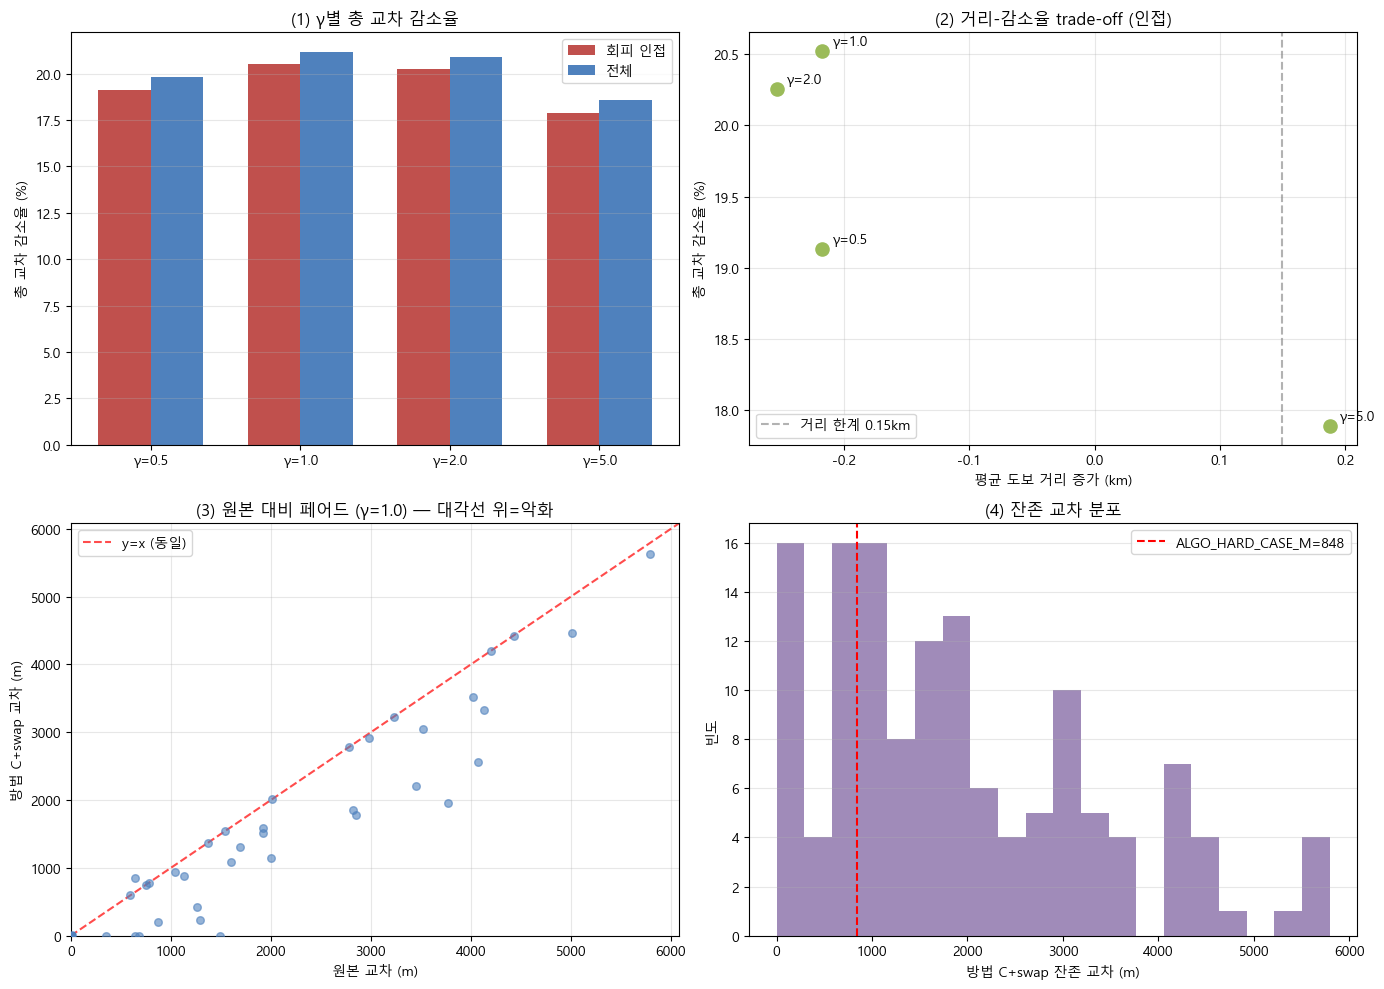

In [16]:
# ==========================================================================
# 셀 18: 단계 6-β 시각화 (1) — γ trade-off 정적 차트 4종
# ==========================================================================
# 핸드오프 v5 16절 근거 자료. 셀 17이 산출한 df_summary/df_sweep/rec_gamma/
# rec_hard_case_m에 의존하므로 셀 17 실행 후에 실행한다.
# 결과 이미지는 output3에 저장하며, Claude 분석용으로 이 PNG 또는
# 셀 17이 만든 CSV를 함께 올린다.

import matplotlib
import matplotlib.pyplot as plt

# 한글 폰트 (Windows 기본: Malgun Gothic). 환경에 따라 'AppleGothic' 등으로 교체한다.
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except Exception:
    pass
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) γ별 총 교차 감소율 — 회피 인접 vs 전체
ax = axes[0, 0]
piv = df_summary.pivot_table(index='gamma', columns='group', values='total_reduction_pct')
x = np.arange(len(piv.index)); w = 0.35
ax.bar(x - w / 2, piv['adjacent'], w, label='회피 인접', color='#c0504d')
ax.bar(x + w / 2, piv['overall'],  w, label='전체',     color='#4f81bd')
ax.set_xticks(x); ax.set_xticklabels([f"γ={g}" for g in piv.index])
ax.set_ylabel('총 교차 감소율 (%)')
ax.set_title('(1) γ별 총 교차 감소율')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# (2) 거리-감소율 trade-off 산점도 (회피 인접 그룹)
ax = axes[0, 1]
adj = df_summary[df_summary['group'] == 'adjacent']
ax.scatter(adj['mean_dist_delta_km'], adj['total_reduction_pct'], s=90, color='#9bbb59', zorder=3)
for _, r in adj.iterrows():
    ax.annotate(f"γ={r['gamma']}", (r['mean_dist_delta_km'], r['total_reduction_pct']),
                textcoords='offset points', xytext=(7, 4))
ax.axvline(DIST_DELTA_LIMIT_KM, color='gray', ls='--', alpha=0.6,
           label=f'거리 한계 {DIST_DELTA_LIMIT_KM}km')
ax.set_xlabel('평균 도보 거리 증가 (km)')
ax.set_ylabel('총 교차 감소율 (%)')
ax.set_title('(2) 거리-감소율 trade-off (인접)')
ax.legend(); ax.grid(alpha=0.3)

# (3) 원본 vs 방법 C+swap 페어드 산점도 (권장 γ) — 대각선 위=악화
ax = axes[1, 0]
one = df_sweep[df_sweep['gamma'] == rec_gamma]
ax.scatter(one['orig_cross_m'], one['v2_cross_m'], s=30, alpha=0.6, color='#4f81bd', zorder=3)
lim = max(one['orig_cross_m'].max(), one['v2_cross_m'].max(), 1.0) * 1.05
ax.plot([0, lim], [0, lim], 'r--', alpha=0.7, label='y=x (동일)')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('원본 교차 (m)')
ax.set_ylabel('방법 C+swap 교차 (m)')
ax.set_title(f'(3) 원본 대비 페어드 (γ={rec_gamma}) — 대각선 위=악화')
ax.legend(); ax.grid(alpha=0.3)

# (4) 잔존 교차 히스토그램 + ALGO_HARD_CASE_M 임계선
ax = axes[1, 1]
resid = df_sweep[df_sweep['v2_cross_m'] > 0]['v2_cross_m']
if len(resid) > 0:
    ax.hist(resid, bins=20, color='#8064a2', alpha=0.75)
ax.axvline(rec_hard_case_m, color='red', ls='--',
           label=f'ALGO_HARD_CASE_M={rec_hard_case_m}')
ax.set_xlabel('방법 C+swap 잔존 교차 (m)')
ax.set_ylabel('빈도')
ax.set_title('(4) 잔존 교차 분포')
ax.legend(); ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
chart_png = BETA_OUTPUT_DIR / 'step6_beta_charts.png'
fig.savefig(chart_png, dpi=120, bbox_inches='tight')
print(f"[차트 저장] {chart_png.resolve()}")
plt.show()



In [17]:
# ==========================================================================
# 셀 19: 단계 6-β 시각화 (2) — 대표 OD 경로 지도 (folium)
# ==========================================================================
# 회피 영역 + 원본 경로 vs 방법 C+swap 경로(권장 γ)를 대표 OD 1개로 시각화한다.
# 대표 OD는 회피 인접·권장 γ에서 교차 감소량이 가장 큰 성공 사례를 선정한다.
# 경로 좌표는 셀 16에 저장하지 않았으므로 대표 OD 1개만 여기서 재계산한다
# (Tmap 캐시가 있으면 대부분 캐시 적중, 없어도 소수 호출에 그친다).

_cand = df_sweep[(df_sweep['gamma'] == rec_gamma) &
                 (df_sweep['group'] == 'adjacent') &
                 (df_sweep['orig_cross_m'] > 0)].copy()

if len(_cand) == 0:
    print("[지도 생략] 회피 인접·교차 발생 OD가 없어 대표 OD를 선정할 수 없다.")
    m = None
else:
    _cand['reduction_m'] = _cand['orig_cross_m'] - _cand['v2_cross_m']
    rep_id = _cand.sort_values('reduction_m', ascending=False).iloc[0]['od_id']
    rep_od = next(od for od in RANDOM_OD if od['od_id'] == rep_id)
    O, D, cands = rep_od['O'], rep_od['D'], rep_od['candidates']
    print(f"[대표 OD] {rep_id} (군구 {rep_od['district']}, 직선 {rep_od['direct_km']:.2f}km)")

    # 원본 경로
    sel_o, _ = algorithm_greedy_original(cands, O, D)
    wp_o = [(r['latitude'], r['longitude']) for _, r in sel_o.iterrows()]
    route_o = get_pedestrian_route(O, D, waypoints=wp_o)
    path_o = route_o['path'] if route_o['status'] == 'OK' else []

    # 방법 C+swap 경로 (권장 γ)
    res = algorithm_greedy_with_avoidance(
        cands, O, D, avoid_union, avoid_union_prepared, avoid_union_by_code,
        gamma=rec_gamma)
    path_v2 = res.get('final_polyline') or []
    sel_v2 = res['final_selection']

    # 지도 생성
    center = [(O[0] + D[0]) / 2, (O[1] + D[1]) / 2]
    m = folium.Map(location=center, zoom_start=14, tiles='CartoDB positron')

    # 회피 영역 (대표 OD 인근 창 안만)
    lat_lo, lat_hi = min(O[0], D[0]) - 0.02, max(O[0], D[0]) + 0.02
    lon_lo, lon_hi = min(O[1], D[1]) - 0.02, max(O[1], D[1]) + 0.02
    for p in avoid_polygons:
        minx, miny, maxx, maxy = p['geom'].bounds   # (lon, lat)
        if maxx < lon_lo or minx > lon_hi or maxy < lat_lo or miny > lat_hi:
            continue
        geom = p['geom']
        polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
        for poly in polys:
            coords = [[y, x] for x, y in poly.exterior.coords]   # (lat, lon)
            folium.Polygon(coords, color='#d9534f', weight=1,
                           fill=True, fill_opacity=0.25,
                           popup=str(p.get('uname', ''))).add_to(m)

    # 경로 (원본=회색, 방법 C+swap=파랑)
    if path_o:
        folium.PolyLine([[la, lo] for la, lo in path_o], color='#7f7f7f',
                        weight=4, opacity=0.9, popup='원본 경로').add_to(m)
    if path_v2:
        folium.PolyLine([[la, lo] for la, lo in path_v2], color='#2b7bba',
                        weight=4, opacity=0.9,
                        popup=f'방법 C+swap (γ={rec_gamma})').add_to(m)

    # O, D 마커
    folium.Marker([O[0], O[1]], popup='출발(O)', icon=folium.Icon(color='green')).add_to(m)
    folium.Marker([D[0], D[1]], popup='도착(D)', icon=folium.Icon(color='red')).add_to(m)

    # 선정 핫스팟 (방법 C+swap)
    for _, r in sel_v2.iterrows():
        folium.CircleMarker([r['latitude'], r['longitude']], radius=5,
                            color='#2b7bba', fill=True, fill_opacity=0.9,
                            popup=f"{r['hotspot_id']} S_i={r['S_i']:.1f}").add_to(m)

    map_html = BETA_OUTPUT_DIR / f'step6_beta_rep_route_{rep_id}.html'
    m.save(str(map_html))
    print(f"[지도 저장] {map_html.resolve()}")

m   # 노트북 인라인 표시 (m이 None이면 아무것도 표시하지 않음)



[대표 OD] R065 (군구 bupyeong, 직선 1.24km)
[지도 저장] C:\Users\User\Documents\GitHub\ploggo-algorithm-test\output3_260727\step6_beta_rep_route_R065.html
